# VinBigData Chest X-ray Abnormalities Detection

## Содержание

- Baseline
- Oversampling + CLAHE
- Weighted Loss + CLAHE
- Визуальный анализ
- Общие выводы

In [1]:
from pathlib import Path
import shutil
import yaml
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO
from pathlib import Path
import zipfile
from collections import Counter
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
ROOT = PROJECT_ROOT / "yolo_data"

In [ ]:
ROOT.mkdir(exist_ok=True)

images_zip = Path("images.zip")
labels_zip = Path("labels.zip")

with zipfile.ZipFile(images_zip, 'r') as z:
    z.extractall(ROOT)

with zipfile.ZipFile(labels_zip, 'r') as z:
    z.extractall(ROOT)

In [4]:
RUNS_ROOT = PROJECT_ROOT  / "yolo_runs"
PRED_ROOT = PROJECT_ROOT  / "yolo_predictions"
TABLES_ROOT = PROJECT_ROOT  / "tables"

RUNS_ROOT.mkdir(parents=True, exist_ok=True)
PRED_ROOT.mkdir(parents=True, exist_ok=True)
TABLES_ROOT.mkdir(parents=True, exist_ok=True)

RUN_NAME = "yolo11n_xray"
FINAL_RUN_NAME = "yolo11n_xray_train_all"

CLASS_NAMES = {
    0: "Aortic enlargement",
    1: "Atelectasis",
    2: "Calcification",
    3: "Cardiomegaly",
    4: "Consolidation",
    5: "ILD",
    6: "Infiltration",
    7: "Lung Opacity",
    8: "Nodule/Mass",
    9: "Other lesion",
    10: "Pleural effusion",
    11: "Pleural thickening",
    12: "Pneumothorax",
    13: "Pulmonary fibrosis"
}

TRAIN_KWARGS = dict(
    epochs=50,
    imgsz=640,
    batch=32,
    workers=4,
    device=0,
    save_period=-1,
    plots=True,
    box=8.0,
    cls=0.3,
    dfl=1.5,
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.0,
    flipud=0.0,
    fliplr=0.3,
    scale=0.2,
    translate=0.1,
    mixup=0.0,
    mosaic=0.1,
    copy_paste=0.0,
    auto_augment=None,
    erasing=0.0
)

FINAL_TRAIN_KWARGS = dict(
    epochs=40,
    imgsz=640,
    batch=32,
    workers=4,
    device=0,
    save_period=-1,
    plots=True,
    box=8.0,
    cls=0.3,
    dfl=1.5,
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.0,
    flipud=0.0,
    fliplr=0.3,
    scale=0.2,
    translate=0.10,
    mixup=0.0,
    mosaic=0.1,
    copy_paste=0.0,
    auto_augment=None,
    erasing=0.0
)

def yolo_to_xyxy(box, w, h):
    x, y, bw, bh = box
    x1 = (x - bw / 2) * w
    y1 = (y - bh / 2) * h
    x2 = (x + bw / 2) * w
    y2 = (y + bh / 2) * h
    return [x1, y1, x2, y2]

def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    union = area1 + area2 - inter + 1e-6
    return inter / union

def read_gt_boxes(label_path, w, h):
    boxes = []
    if not label_path.exists():
        return boxes
    text = label_path.read_text().strip()
    if not text:
        return boxes
    for line in text.splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        cls, x, y, bw, bh = map(float, parts)
        boxes.append({"cls": int(cls), "box": yolo_to_xyxy([x, y, bw, bh], w, h)})
    return boxes

def read_pred_boxes(label_path, w, h):
    boxes = []
    if not label_path.exists():
        return boxes
    text = label_path.read_text().strip()
    if not text:
        return boxes
    for line in text.splitlines():
        parts = line.split()
        if len(parts) != 6:
            continue
        cls, x, y, bw, bh, conf = map(float, parts)
        boxes.append({
            "cls": int(cls),
            "box": yolo_to_xyxy([x, y, bw, bh], w, h),
            "conf": float(conf)
        })
    return boxes

def build_data_yaml(root: Path, train_split: str, val_split: str, test_split: str, out_name: str):
    data = {
        "path": str(root),
        "train": train_split,
        "val": val_split,
        "test": test_split,
        "names": [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)]
    }
    out_path = root / out_name
    with open(out_path, "w", encoding="utf-8") as f:
        yaml.dump(data, f, sort_keys=False, allow_unicode=True)
    print(out_path.read_text(encoding="utf-8"))
    return out_path

def make_train_all(root: Path):
    train_all_img = root / "images" / "train_all"
    train_all_lbl = root / "labels" / "train_all"
    train_all_img.mkdir(parents=True, exist_ok=True)
    train_all_lbl.mkdir(parents=True, exist_ok=True)
    for split in ["train", "val"]:
        for p in (root / "images" / split).glob("*"):
            dst = train_all_img / p.name
            if not dst.exists():
                shutil.copy2(p, dst)
        for p in (root / "labels" / split).glob("*"):
            dst = train_all_lbl / p.name
            if not dst.exists():
                shutil.copy2(p, dst)
    print("train_all images:", len(list(train_all_img.glob("*"))))
    print("train_all labels:", len(list(train_all_lbl.glob("*"))))
    return train_all_img, train_all_lbl

def evaluate_predictions_by_class(img_dir: Path, gt_dir: Path, pred_dir: Path, class_names: dict, iou_thr: float = 0.5):
    stats = {cls_id: {"GT": 0, "Pred": 0, "TP": 0, "FP": 0, "FN": 0} for cls_id in class_names}
    for img_path in img_dir.glob("*"):
        if img_path.suffix.lower() not in [".png", ".jpg", ".jpeg"]:
            continue
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]
        gt_boxes = read_gt_boxes(gt_dir / f"{img_path.stem}.txt", w, h)
        pred_boxes = read_pred_boxes(pred_dir / f"{img_path.stem}.txt", w, h)
        for gt in gt_boxes:
            stats[gt["cls"]]["GT"] += 1
        for pred in pred_boxes:
            stats[pred["cls"]]["Pred"] += 1

        matched_gt = set()
        matched_pred = set()
        for pi, pred in enumerate(pred_boxes):
            best_iou = 0.0
            best_gi = None
            for gi, gt in enumerate(gt_boxes):
                if gi in matched_gt or pred["cls"] != gt["cls"]:
                    continue
                cur_iou = iou(pred["box"], gt["box"])
                if cur_iou > best_iou:
                    best_iou = cur_iou
                    best_gi = gi
            if best_gi is not None and best_iou >= iou_thr:
                matched_pred.add(pi)
                matched_gt.add(best_gi)
                stats[pred["cls"]]["TP"] += 1

        for pi, pred in enumerate(pred_boxes):
            if pi not in matched_pred:
                stats[pred["cls"]]["FP"] += 1
        for gi, gt in enumerate(gt_boxes):
            if gi not in matched_gt:
                stats[gt["cls"]]["FN"] += 1

    rows = []
    for cls_id, name in class_names.items():
        tp = stats[cls_id]["TP"]
        fp = stats[cls_id]["FP"]
        fn = stats[cls_id]["FN"]
        gt = stats[cls_id]["GT"]
        pred = stats[cls_id]["Pred"]
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        rows.append({
            "class_id": cls_id,
            "class_name": name,
            "GT": gt,
            "Pred": pred,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1": round(f1, 4),
        })
    return pd.DataFrame(rows).sort_values(["Recall", "Precision"], ascending=[True, True]).reset_index(drop=True)

def match_for_class(gt_boxes, pred_boxes, class_id, conf_thr, iou_thr=0.5):
    gt_cls = [g for g in gt_boxes if g["cls"] == class_id]
    pred_cls = [p for p in pred_boxes if p["cls"] == class_id and p["conf"] >= conf_thr]
    matched_gt = set()
    matched_pred = set()
    for pi, pred in enumerate(pred_cls):
        best_iou = 0.0
        best_gi = None
        for gi, gt in enumerate(gt_cls):
            if gi in matched_gt:
                continue
            cur_iou = iou(pred["box"], gt["box"])
            if cur_iou > best_iou:
                best_iou = cur_iou
                best_gi = gi
        if best_gi is not None and best_iou >= iou_thr:
            matched_pred.add(pi)
            matched_gt.add(best_gi)
    tp = len(matched_pred)
    fp = len(pred_cls) - len(matched_pred)
    fn = len(gt_cls) - len(matched_gt)
    return tp, fp, fn

def fbeta_score(precision, recall, beta=2.0):
    if precision == 0 and recall == 0:
        return 0.0
    b2 = beta ** 2
    return (1 + b2) * precision * recall / (b2 * precision + recall + 1e-12)

def find_best_thresholds(val_img_dir: Path, val_gt_dir: Path, val_pred_dir: Path, class_names: dict,
                         thresholds=None, iou_thr=0.5, beta=2.0):
    if thresholds is None:
        thresholds = np.round(np.arange(0.01, 0.51, 0.01), 2)

    image_paths = [p for p in val_img_dir.glob("*") if p.suffix.lower() in [".png", ".jpg", ".jpeg"]]

    cache = []
    for img_path in image_paths:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]
        gt_boxes = read_gt_boxes(val_gt_dir / f"{img_path.stem}.txt", w, h)
        pred_boxes = read_pred_boxes(val_pred_dir / f"{img_path.stem}.txt", w, h)
        cache.append((gt_boxes, pred_boxes))

    rows = []
    score_col = f"F{int(beta)}"

    for class_id in class_names:
        best_row = None
        for thr in thresholds:
            TP = FP = FN = 0
            for gt_boxes, pred_boxes in cache:
                tp, fp, fn = match_for_class(gt_boxes, pred_boxes, class_id, thr, iou_thr=iou_thr)
                TP += tp
                FP += fp
                FN += fn

            precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
            recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
            f1 = fbeta_score(precision, recall, beta=1.0)
            fbeta = fbeta_score(precision, recall, beta=beta)

            row = {
                "class_id": class_id,
                "class_name": class_names[class_id],
                "threshold": float(thr),
                "TP": TP,
                "FP": FP,
                "FN": FN,
                "Precision": precision,
                "Recall": recall,
                "F1": f1,
                score_col: fbeta,
            }

            if best_row is None or row[score_col] > best_row[score_col]:
                best_row = row
        rows.append(best_row)

    return pd.DataFrame(rows).sort_values("class_id").reset_index(drop=True)

def filter_prediction_labels_by_threshold(src_pred_dir: Path, dst_pred_dir: Path, thresholds_df: pd.DataFrame):
    dst_pred_dir.mkdir(parents=True, exist_ok=True)
    thr_map = dict(zip(thresholds_df["class_id"], thresholds_df["threshold"]))
    for txt_path in src_pred_dir.glob("*.txt"):
        kept_lines = []
        text = txt_path.read_text().strip()
        if text:
            for line in text.splitlines():
                parts = line.split()
                if len(parts) != 6:
                    continue
                cls, x, y, bw, bh, conf = map(float, parts)
                cls = int(cls)
                if conf >= thr_map.get(cls, 0.05):
                    kept_lines.append(line)
        out_path = dst_pred_dir / txt_path.name
        out_path.write_text("\n".join(kept_lines), encoding="utf-8")

def print_conclusions_from_df(df_class: pd.DataFrame, title: str = "Выводы"):
    worst_recall = df_class.nsmallest(5, "Recall")[["class_name", "Recall", "FN"]]
    worst_precision = df_class.nsmallest(5, "Precision")[["class_name", "Precision", "FP"]]
    best_classes = df_class.nlargest(3, "F1")[["class_name", "Precision", "Recall", "F1"]]
    print(title)
    print("-" * len(title))
    print("Самые проблемные классы по recall:")
    print(worst_recall.to_string(index=False))
    print("\nСамые проблемные классы по precision:")
    print(worst_precision.to_string(index=False))
    print("\nЛучшие классы по F1:")
    print(best_classes.to_string(index=False))

def collect_fp_fn_errors(
    img_dir: Path,
    gt_dir: Path,
    pred_dir: Path,
    class_names: dict,
    iou_thr: float = 0.5
):
    false_positives = []
    false_negatives = []

    for img_path in img_dir.glob("*"):
        if img_path.suffix.lower() not in [".png", ".jpg", ".jpeg"]:
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue

        h, w = img.shape[:2]

        gt_boxes = read_gt_boxes(gt_dir / f"{img_path.stem}.txt", w, h)
        pred_boxes = read_pred_boxes(pred_dir / f"{img_path.stem}.txt", w, h)

        matched_gt = set()
        matched_pred = set()

        for pi, pred in enumerate(pred_boxes):
            best_iou = 0.0
            best_gi = None

            for gi, gt in enumerate(gt_boxes):
                if gi in matched_gt:
                    continue

                if pred["cls"] != gt["cls"]:
                    continue

                cur_iou = iou(pred["box"], gt["box"])

                if cur_iou > best_iou:
                    best_iou = cur_iou
                    best_gi = gi

            if best_gi is not None and best_iou >= iou_thr:
                matched_pred.add(pi)
                matched_gt.add(best_gi)

        for pi, pred in enumerate(pred_boxes):
            if pi not in matched_pred:
                false_positives.append({
                    "image_id": img_path.stem,
                    "image_path": img_path,
                    "class_id": pred["cls"],
                    "class_name": class_names[pred["cls"]],
                    "conf": pred.get("conf", None),
                    "box": pred["box"],
                })

        for gi, gt in enumerate(gt_boxes):
            if gi not in matched_gt:
                false_negatives.append({
                    "image_id": img_path.stem,
                    "image_path": img_path,
                    "class_id": gt["cls"],
                    "class_name": class_names[gt["cls"]],
                    "box": gt["box"],
                })

    fp_df = pd.DataFrame(false_positives)
    fn_df = pd.DataFrame(false_negatives)

    if not fp_df.empty:
        fp_df = fp_df.sort_values("conf", ascending=False).reset_index(drop=True)

    return fp_df, fn_df

def safe_name(name):
    return str(name).replace("/", "_").replace(" ", "_")


def draw_box(img, box, label, color, thickness=2):
    x1, y1, x2, y2 = map(int, box)

    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)

    cv2.putText(
        img,
        label,
        (x1, max(y1 - 8, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        color,
        1,
        cv2.LINE_AA
    )

def save_fp_images(fp_df, out_dir, top_n=100):
    out_dir.mkdir(parents=True, exist_ok=True)

    for i, row in fp_df.head(top_n).iterrows():
        img = cv2.imread(str(row["image_path"]))
        if img is None:
            continue

        label = f'FP {row["class_name"]} {row["conf"]:.2f}'
        draw_box(img, row["box"], label, color=(0, 0, 255))

        out_path = out_dir / f'{i:03d}_{row["image_id"]}_FP_{safe_name(row["class_name"])}.png'
        cv2.imwrite(str(out_path), img)


def save_fn_images(fn_df, out_dir, top_n=100):
    out_dir.mkdir(parents=True, exist_ok=True)

    for i, row in fn_df.head(top_n).iterrows():
        img = cv2.imread(str(row["image_path"]))
        if img is None:
            continue

        label = f'FN {row["class_name"]}'
        draw_box(img, row["box"], label, color=(0, 255, 0))

        out_path = out_dir / f'{i:03d}_{row["image_id"]}_FN_{safe_name(row["class_name"])}.png'
        cv2.imwrite(str(out_path), img)

def show_error(row, title="", color=(255, 0, 0)):
    img = cv2.imread(str(row["image_path"]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    x1, y1, x2, y2 = map(int, row["box"])

    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

    label = f'{row["class_name"]} | conf={row.get("conf", 0):.2f}'
    cv2.putText(
        img,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        color,
        2,
        cv2.LINE_AA
    )

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

## Проверка классов и создание `data.yaml`

In [ ]:
LABELS_ROOT = ROOT / "labels"
class_ids = set()
label_files = list(LABELS_ROOT.rglob("*.txt"))

for file in label_files:
    with open(file, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            class_ids.add(int(line.split()[0]))

DATA_YAML = build_data_yaml(
    root=ROOT,
    train_split="images/train",
    val_split="images/val",
    test_split="images/test",
    out_name="data.yaml",
)

path: /home/katyukh/projects/VinBigData/yolo_data
train: images/train
val: images/val
test: images/test
names:
- Aortic enlargement
- Atelectasis
- Calcification
- Cardiomegaly
- Consolidation
- ILD
- Infiltration
- Lung Opacity
- Nodule/Mass
- Other lesion
- Pleural effusion
- Pleural thickening
- Pneumothorax
- Pulmonary fibrosis



## 1. Baseline

### Обучение модели на `train` и проверка на `val`

In [ ]:
train_kwargs = dict(
    data=str(DATA_YAML),
    project=str(RUNS_ROOT),
    name=RUN_NAME,
    patience=20,
    **TRAIN_KWARGS,
)

model = YOLO("yolo11n.pt")
results = model.train(**train_kwargs)

In [ ]:
BEST_WEIGHTS = RUNS_ROOT / RUN_NAME / "weights" / "best.pt"
print(BEST_WEIGHTS)

/home/katyukh/projects/VinBigData/yolo_runs/yolo11n_xray/weights/best.pt


### Обучение на `train + val` и проверка на `test`

In [ ]:
make_train_all(ROOT)

DATA_TRAIN_ALL_YAML = build_data_yaml(
    root=ROOT,
    train_split="images/train_all",
    val_split="images/test",
    test_split="images/test",
    out_name="data_train_all.yaml",
)

final_train_kwargs = dict(
    data=str(DATA_TRAIN_ALL_YAML),
    project=str(RUNS_ROOT),
    name=FINAL_RUN_NAME,
    patience=0,
    **FINAL_TRAIN_KWARGS,
)

final_model = YOLO("yolo11n.pt")
final_results = final_model.train(**final_train_kwargs)

In [ ]:
BEST_WEIGHTS_FINAL = RUNS_ROOT / FINAL_RUN_NAME / "weights" / "best.pt"
print(BEST_WEIGHTS_FINAL)

/home/katyukh/projects/VinBigData/yolo_runs/yolo11n_xray_train_all/weights/best.pt


### Предсказания на `test` с лучшими весами

In [ ]:

best_model_final = YOLO(str(BEST_WEIGHTS_FINAL))

test_pred_results = best_model_final.predict(
    source=str(ROOT / "images/test"),
    imgsz=640,
    conf=0.05,
    iou=0.5,
    augment=True,
    save=False,
    save_txt=True,
    save_conf=True,
    project=str(PRED_ROOT),
    name="test_preds_final_best",
    exist_ok=True
)

### Табличный анализ ошибок по классам на `test`

In [ ]:
IMG_DIR = ROOT / "images/test"
GT_DIR = ROOT / "labels/test"
TEST_PRED_DIR = PRED_ROOT / "test_preds_final_best" / "labels"

df_test_class = evaluate_predictions_by_class(
    img_dir=IMG_DIR,
    gt_dir=GT_DIR,
    pred_dir=TEST_PRED_DIR,
    class_names=CLASS_NAMES,
    iou_thr=0.5,
)

df_test_class

,class_id,class_name,GT,Pred,TP,FP,FN,Precision,Recall,F1
0,1,Atelectasis,13,16,0,16,13,0.0000,0.0000,0.0000
1,4,Consolidation,26,30,3,27,23,0.1000,0.1154,0.1071
2,9,Other lesion,252,836,64,772,188,0.0766,0.2540,0.1176
3,2,Calcification,78,265,20,245,58,0.0755,0.2564,0.1166
4,12,Pneumothorax,25,56,7,49,18,0.1250,0.2800,0.1728
5,6,Infiltration,74,146,23,123,51,0.1575,0.3108,0.2091
6,8,Nodule/Mass,350,848,139,709,211,0.1639,0.3971,0.2321
7,7,Lung Opacity,248,850,113,737,135,0.1329,0.4556,0.2058
8,13,Pulmonary fibrosis,581,1639,270,1369,311,0.1647,0.4647,0.2432
9,11,Pleural thickening,793,2472,377,2095,416,0.1525,0.4754,0.2309


In [ ]:
df_test_class.to_csv(TABLES_ROOT / 'results_baseline.csv', index=False)

In [ ]:
print_conclusions_from_df(df_test_class, title="Выводы по test до подбора порогов")

Выводы по test до подбора порогов
---------------------------------
Самые проблемные классы по recall:
   class_name  Recall  FN
  Atelectasis  0.0000  13
Consolidation  0.1154  23
 Other lesion  0.2540 188
Calcification  0.2564  58
 Pneumothorax  0.2800  18

Самые проблемные классы по precision:
   class_name  Precision  FP
  Atelectasis     0.0000  16
Calcification     0.0755 245
 Other lesion     0.0766 772
Consolidation     0.1000  27
 Pneumothorax     0.1250  49

Лучшие классы по F1:
        class_name  Precision  Recall     F1
      Cardiomegaly     0.5960  0.9706 0.7385
Aortic enlargement     0.5762  0.9613 0.7206
  Pleural effusion     0.2507  0.7227 0.3723


Бейзлайн хорошо детектирует частые классы, такие как Aortic enlargement и Cardiomegaly, однако показывает низкое качество на редких патологиях. Atelectasis полностью отсутствует в предсказаниях, а Consolidation и Calcification имеют очень низкий recall и F1.

### Подбор `per-class` порогов на val

In [ ]:
best_model = YOLO(str(BEST_WEIGHTS))

val_pred_results = best_model.predict(
    source=str(ROOT / "images/val"),
    imgsz=640,
    conf=0.001,
    iou=0.5,
    augment=True,
    save=False,
    save_txt=True,
    save_conf=True,
    project=str(PRED_ROOT),
    name="val_preds_raw_lowconf",
    exist_ok=True
)

In [ ]:
VAL_IMG_DIR = ROOT / "images/val"
VAL_GT_DIR = ROOT / "labels/val"
VAL_PRED_DIR = PRED_ROOT / "val_preds_raw_lowconf" / "labels"

df_best_thr = find_best_thresholds(
    val_img_dir=VAL_IMG_DIR,
    val_gt_dir=VAL_GT_DIR,
    val_pred_dir=VAL_PRED_DIR,
    class_names=CLASS_NAMES,
    thresholds=np.round(np.arange(0.01, 0.51, 0.01), 2),
    iou_thr=0.5,
    beta=2.0,
)

df_best_thr

,class_id,class_name,threshold,TP,FP,FN,Precision,Recall,F1,F2
0,0,Aortic enlargement,0.37,417,112,42,0.788280,0.908497,0.844130,0.881607
1,1,Atelectasis,0.01,0,18,7,0.000000,0.000000,0.000000,0.000000
2,2,Calcification,0.02,18,223,36,0.074689,0.333333,0.122034,0.196937
3,3,Cardiomegaly,0.25,322,87,23,0.787286,0.933333,0.854111,0.899944
4,4,Consolidation,0.04,3,15,8,0.166667,0.272727,0.206897,0.241935
5,5,ILD,0.12,26,111,40,0.189781,0.393939,0.256158,0.324190
6,6,Infiltration,0.07,13,75,19,0.147727,0.406250,0.216667,0.300926
7,7,Lung Opacity,0.12,40,167,88,0.193237,0.312500,0.238806,0.278164
8,8,Nodule/Mass,0.12,76,262,125,0.224852,0.378109,0.282004,0.332750
9,9,Other lesion,0.14,22,112,116,0.164179,0.159420,0.161765,0.160350


In [ ]:
df_best_thr.to_csv(TABLES_ROOT / 'thresholds.csv', index=False)

Самые проблемные и редкие классы: Atelectasis, Consolidation, Pneumothorax, Calcification. Для Atelectasis, Consolidation, Calcification оптимальный порог подобран ниже, чем изначальный (0.05). Для Pneumothorax гораздо выше: 0.38.


### Применение найденных порогов к `test` и сравнение с бейзлайном

In [ ]:

best_model_final = YOLO(str(BEST_WEIGHTS_FINAL))

test_pred_results_lowconf = best_model_final.predict(
    source=str(ROOT / "images/test"),
    imgsz=640,
    conf=0.01,
    iou=0.5,
    augment=True,
    save=False,
    save_txt=True,
    save_conf=True,
    project=str(PRED_ROOT),
    name="test_preds_final_lowconf",
    exist_ok=True
)

TEST_PRED_LOWCONF_DIR = PRED_ROOT / "test_preds_final_lowconf" / "labels"
TEST_PRED_FILTERED_DIR = PRED_ROOT / "test_preds_final_filtered_by_class" / "labels"

filter_prediction_labels_by_threshold(
    src_pred_dir=TEST_PRED_LOWCONF_DIR,
    dst_pred_dir=TEST_PRED_FILTERED_DIR,
    thresholds_df=df_best_thr
)

df_test_class_filtered = evaluate_predictions_by_class(
    img_dir=ROOT / "images/test",
    gt_dir=ROOT / "labels/test",
    pred_dir=TEST_PRED_FILTERED_DIR,
    class_names=CLASS_NAMES,
    iou_thr=0.5,
)

comparison = df_test_class.merge(
    df_test_class_filtered,
    on=["class_id", "class_name", "GT"],
    suffixes=("_base", "_filtered")
)

comparison[[
    "class_id", "class_name",
    "Precision_base", "Recall_base", "F1_base",
    "Precision_filtered", "Recall_filtered", "F1_filtered"
]].sort_values("class_id")


In [ ]:
comparison.to_csv(TABLES_ROOT / 'thresholds_vs_baseline.csv', index=False)

In [6]:
comparison = pd.read_csv(TABLES_ROOT / 'thresholds_vs_baseline.csv')
comparison[[
    "class_id", "class_name",
    "Precision_base", "Recall_base", "F1_base",
    "Precision_filtered", "Recall_filtered", "F1_filtered"
]].sort_values("class_id")


,class_id,class_name,Precision_base,Recall_base,F1_base,Precision_filtered,Recall_filtered,F1_filtered
12,0,Aortic enlargement,0.5762,0.9613,0.7206,0.8231,0.8878,0.8542
0,1,Atelectasis,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,2,Calcification,0.0755,0.2564,0.1166,0.0503,0.3846,0.0889
13,3,Cardiomegaly,0.5960,0.9706,0.7385,0.7438,0.9326,0.8276
1,4,Consolidation,0.1000,0.1154,0.1071,0.0882,0.1154,0.1000
10,5,ILD,0.1473,0.5820,0.2351,0.2355,0.4672,0.3132
5,6,Infiltration,0.1575,0.3108,0.2091,0.1901,0.3108,0.2359
7,7,Lung Opacity,0.1329,0.4556,0.2058,0.2087,0.3669,0.2661
6,8,Nodule/Mass,0.1639,0.3971,0.2321,0.2843,0.3314,0.3061
2,9,Other lesion,0.0766,0.2540,0.1176,0.1654,0.1706,0.1680


In [ ]:
print_conclusions_from_df(df_test_class_filtered, title="Выводы по test после per-class thresholds")

Выводы по test после per-class thresholds
-----------------------------------------
Самые проблемные классы по recall:
   class_name  Recall  FN
  Atelectasis  0.0000  13
Consolidation  0.1154  23
 Other lesion  0.1706 209
 Pneumothorax  0.2400  19
 Infiltration  0.3108  51

Самые проблемные классы по precision:
   class_name  Precision  FP
  Atelectasis     0.0000  29
Calcification     0.0503 567
Consolidation     0.0882  31
 Other lesion     0.1654 217
 Infiltration     0.1901  98

Лучшие классы по F1:
        class_name  Precision  Recall     F1
Aortic enlargement     0.8231  0.8878 0.8542
      Cardiomegaly     0.7438  0.9326 0.8276
  Pleural effusion     0.2948  0.6218 0.4000


По сравнению с бейзлайном, использование разных порогов позволило уменьшить количество `FP` для большинства классов и повысить `precision`. Особенно заметно улучшилось качество детекции для `Aortic enlargement` и `Cardiomegaly`. Также вырос `F1-score` у `Nodule/Mass`, `ILD`, `Pleural effusion`, `Other Lesion`, `Pneumothorax`, `Infiltration`, `Lung Opacity`, `Pulmonary fibrosis`, `Pleural thickening`.

Для некоторых патологий `recall` немного снизился, так как модель стала делать более осторожные предсказания, однако уменьшение количества `FP` компенсировало эту потерю и в итоге улучшило общий баланс качества.

При этом часть сложных и редких классов, таких как `Atelectasis` и `Consolidation`, всё еще распознаются плохо. Изменение порогов практически не помогло `Atelectasis`, что может указывать на проблемы с количеством данных, качеством разметки.

В целом подбор отдельных порогов для каждого класса показал себя эффективнее использования единого порога.

## 2. CLAHE + Oversampling

In [ ]:
TRAIN_IMG_DIR = ROOT / 'images' / 'train'
TRAIN_LBL_DIR = ROOT / 'labels' / 'train'

In [ ]:
counter = Counter()

for lbl in TRAIN_LBL_DIR.glob('*.txt'):
    with open(lbl) as f:
        for line in f:
            if line.strip():
                cls = int(line.split()[0])
                counter[cls] += 1

for cls, count in sorted(counter.items()):
    print(cls, CLASS_NAMES[cls], count)

0 Aortic enlargement 1834
1 Atelectasis 33
2 Calcification 221
3 Cardiomegaly 1367
4 Consolidation 56
5 ILD 274
6 Infiltration 180
7 Lung Opacity 586
8 Nodule/Mass 994
9 Other lesion 631
10 Pleural effusion 332
11 Pleural thickening 1980
12 Pneumothorax 49
13 Pulmonary fibrosis 1477


### Создание CLAHE-копий

Применяется ко всем изображением. То есть после создания копий изображений станет в два раза больше.

In [ ]:
CLAHE_CLIP = 1.5
CLAHE_TILE = (4,4)

In [ ]:
RARE_CLASSES = [1, 4, 12, 2]  # Atelectasis, Consolidation, Pneumothorax, Calcification

def apply_clahe(img):
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)
    g = clahe.apply(g)
    return cv2.cvtColor(g, cv2.COLOR_GRAY2BGR)

def get_classes(label):
    with open(label) as f:
        return [int(l.split()[0]) for l in f if l.strip()]


for img_path in TRAIN_IMG_DIR.glob('*'):
    if not img_path.exists():
        continue

    im = cv2.imread(str(img_path))
    if im is None:
        continue

    lbl_path = TRAIN_LBL_DIR / f'{img_path.stem}.txt'
    if not lbl_path.exists():
        continue

    out = apply_clahe(im)
    new_img = TRAIN_IMG_DIR / f'{img_path.stem}_clahe{img_path.suffix}'
    new_lbl = TRAIN_LBL_DIR / f'{img_path.stem}_clahe.txt'
    cv2.imwrite(str(new_img), out)
    shutil.copy2(lbl_path, new_lbl)

In [ ]:
counter = Counter()

for lbl in TRAIN_LBL_DIR.glob('*.txt'):
    with open(lbl) as f:
        for line in f:
            if line.strip():
                cls = int(line.split()[0])
                counter[cls] += 1

for cls, count in sorted(counter.items()):
    print(cls, CLASS_NAMES[cls], count)

0 Aortic enlargement 3668
1 Atelectasis 66
2 Calcification 442
3 Cardiomegaly 2734
4 Consolidation 112
5 ILD 548
6 Infiltration 360
7 Lung Opacity 1172
8 Nodule/Mass 1988
9 Other lesion 1262
10 Pleural effusion 664
11 Pleural thickening 3960
12 Pneumothorax 98
13 Pulmonary fibrosis 2954


### Oversampling

Применяется к рентгенам, содержащим редкие классы. Поэтому вместе с редкими классами могут увеличиваться и частые. Оверсемплятся как оригиналы, так и CLAHE-версии.

In [ ]:
TARGET_PER_CLASS = int(np.median(list(counter.values())))

OVERSAMPLE_BY_CLASS = {
    cls: max(1, round(TARGET_PER_CLASS / counter[cls]))
    for cls in RARE_CLASSES
    if counter[cls] < TARGET_PER_CLASS
}

print("Counter:", dict(sorted(counter.items())))
print("Multipliers:", OVERSAMPLE_BY_CLASS)

Counter: {0: 3668, 1: 66, 2: 442, 3: 2734, 4: 112, 5: 548, 6: 360, 7: 1172, 8: 1988, 9: 1262, 10: 664, 11: 3960, 12: 98, 13: 2954}
Multipliers: {1: 14, 4: 8, 12: 9, 2: 2}


In [ ]:
def get_multiplier(classes):
    multipliers = [OVERSAMPLE_BY_CLASS.get(c, 1) for c in classes]
    return max(multipliers)

for img_path in TRAIN_IMG_DIR.glob('*'):
    name = img_path.stem

    # Только оригиналы (без _clahe и _aug)
    if '_clahe' in name or '_aug' in name:
        continue

    if not img_path.exists():
        continue

    lbl_path = TRAIN_LBL_DIR / f'{name}.txt'
    if not lbl_path.exists():
        continue

    classes = get_classes(lbl_path)
    if not classes:
        continue

    if not any(c in RARE_CLASSES for c in classes):
        continue

    multiplier = get_multiplier(classes)
    if multiplier <= 1:
        continue

    total_dup = multiplier - 1
    n_orig = total_dup // 2
    n_clahe = total_dup - n_orig

    # Дубли оригинала
    for i in range(n_orig):
        new_img = TRAIN_IMG_DIR / f'{name}_aug_orig_{i}{img_path.suffix}'
        new_lbl = TRAIN_LBL_DIR / f'{name}_aug_orig_{i}.txt'
        shutil.copy2(img_path, new_img)
        shutil.copy2(lbl_path, new_lbl)

    # Дубли CLAHE
    clahe_img = TRAIN_IMG_DIR / f'{name}_clahe{img_path.suffix}'
    clahe_lbl = TRAIN_LBL_DIR / f'{name}_clahe.txt'

    if clahe_img.exists():
        for i in range(n_clahe):
            new_img = TRAIN_IMG_DIR / f'{name}_aug_clahe_{i}{img_path.suffix}'
            new_lbl = TRAIN_LBL_DIR / f'{name}_aug_clahe_{i}.txt'
            shutil.copy2(clahe_img, new_img)
            shutil.copy2(clahe_lbl, new_lbl)
    else:
        for i in range(n_orig, total_dup):
            new_img = TRAIN_IMG_DIR / f'{name}_aug_orig_{i}{img_path.suffix}'
            new_lbl = TRAIN_LBL_DIR / f'{name}_aug_orig_{i}.txt'
            shutil.copy2(img_path, new_img)
            shutil.copy2(lbl_path, new_lbl)

In [ ]:
counter = Counter()

for lbl in TRAIN_LBL_DIR.glob('*.txt'):
    with open(lbl) as f:
        for line in f:
            if line.strip():
                cls = int(line.split()[0])
                counter[cls] += 1

for cls, count in sorted(counter.items()):
    print(cls, CLASS_NAMES[cls], count)

0 Aortic enlargement 4093
1 Atelectasis 495
2 Calcification 771
3 Cardiomegaly 3030
4 Consolidation 522
5 ILD 661
6 Infiltration 505
7 Lung Opacity 1568
8 Nodule/Mass 2487
9 Other lesion 1771
10 Pleural effusion 1109
11 Pleural thickening 4911
12 Pneumothorax 490
13 Pulmonary fibrosis 3878


### Обучение на `train + val` и проверка на `test`

In [ ]:
make_train_all(ROOT)

DATA_TRAIN_ALL_YAML = build_data_yaml(
    root=ROOT,
    train_split="images/train_all",
    val_split="images/test",
    test_split="images/test",
    out_name="data_train_all.yaml",
)

final_train_kwargs = dict(
    data=str(DATA_TRAIN_ALL_YAML),
    project=str(RUNS_ROOT),
    name='yolo11n_xray_clahe_oversampling',
    patience=0,
    **FINAL_TRAIN_KWARGS,
)

final_model = YOLO("yolo11n.pt")
final_results = final_model.train(**final_train_kwargs)

In [ ]:
BEST_WEIGHTS_CLAHE_OVERSAMPLING = RUNS_ROOT / 'yolo11n_xray_clahe_oversampling' / "weights" / "best.pt"
print(BEST_WEIGHTS_CLAHE_OVERSAMPLING)

/home/katyukh/projects/VinBigData/yolo_runs/yolo11n_xray_clahe_oversampling/weights/best.pt


- предикт 0.05 как в бейзлайне
- подбор порога
- предикт с нормальным порогом

### Предсказание на test с единым порогом 0.05

In [ ]:
best_model_final = YOLO(str(BEST_WEIGHTS_CLAHE_OVERSAMPLING))

test_pred_results = best_model_final.predict(
    source=str(ROOT / "images/test"),
    imgsz=640,
    conf=0.05,
    iou=0.5,
    augment=True,
    save=False,
    save_txt=True,
    save_conf=True,
    project=str(PRED_ROOT),
    name="test_preds_clahe_oversampling_baseline_threshold",
    exist_ok=True
)

#### Табличный анализ ошибок

In [ ]:
IMG_DIR = ROOT / "images/test"
GT_DIR = ROOT / "labels/test"
TEST_PRED_DIR = PRED_ROOT / "test_preds_clahe_oversampling_baseline_threshold" / "labels"

df_test_class = evaluate_predictions_by_class(
    img_dir=IMG_DIR,
    gt_dir=GT_DIR,
    pred_dir=TEST_PRED_DIR,
    class_names=CLASS_NAMES,
    iou_thr=0.5,
)

df_test_class

,class_id,class_name,GT,Pred,TP,FP,FN,Precision,Recall,F1
0,4,Consolidation,26,63,3,60,23,0.0476,0.1154,0.0674
1,1,Atelectasis,13,26,2,24,11,0.0769,0.1538,0.1026
2,9,Other lesion,252,392,40,352,212,0.1020,0.1587,0.1242
3,2,Calcification,78,190,15,175,63,0.0789,0.1923,0.1119
4,12,Pneumothorax,25,59,9,50,16,0.1525,0.3600,0.2143
5,6,Infiltration,74,167,27,140,47,0.1617,0.3649,0.2241
6,7,Lung Opacity,248,704,91,613,157,0.1293,0.3669,0.1912
7,13,Pulmonary fibrosis,581,1228,216,1012,365,0.1759,0.3718,0.2388
8,8,Nodule/Mass,350,704,134,570,216,0.1903,0.3829,0.2543
9,11,Pleural thickening,793,1826,304,1522,489,0.1665,0.3834,0.2321


In [ ]:
df_test_class.to_csv(TABLES_ROOT / 'results_oversampling_clahe_baseline_threshold.csv', index=False)

In [ ]:
print_conclusions_from_df(df_test_class , title="Выводы по test с CLAHE и Oversampling и единым порогом")

Выводы по test с CLAHE и Oversampling и единым порогом
------------------------------------------------------
Самые проблемные классы по recall:
   class_name  Recall  FN
Consolidation  0.1154  23
  Atelectasis  0.1538  11
 Other lesion  0.1587 212
Calcification  0.1923  63
 Pneumothorax  0.3600  16

Самые проблемные классы по precision:
   class_name  Precision  FP
Consolidation     0.0476  60
  Atelectasis     0.0769  24
Calcification     0.0789 175
 Other lesion     0.1020 352
 Lung Opacity     0.1293 613

Лучшие классы по F1:
        class_name  Precision  Recall     F1
Aortic enlargement     0.6218  0.9514 0.7521
      Cardiomegaly     0.5493  0.9810 0.7043
  Pleural effusion     0.2580  0.6807 0.3741


`Oversampling` позволил модели начать детектировать `Atelectasis`, однако улучшение оказалось нестабильным. Вместе с редкими классами также увеличилось количество объектов частых патологий, поскольку `oversampling` выполнялся на уровне изображений.

### Подбор `per-class` порогов на `val`

#### Обучение на `train` с проверкой на `val`

In [ ]:
train_kwargs = dict(
    data=str(DATA_YAML),
    project=str(RUNS_ROOT),
    name='yolo11n_xray_oversampling_clahe_train_val',
    patience=20,
    **TRAIN_KWARGS,
)

model = YOLO("yolo11n.pt")
results = model.train(**train_kwargs)

In [ ]:
BEST_WEIGHTS = RUNS_ROOT / 'yolo11n_xray_oversampling_clahe_train_val' / "weights" / "best.pt"
print(BEST_WEIGHTS)

/home/katyukh/projects/VinBigData/yolo_runs/yolo11n_xray_oversampling_clahe_train_val/weights/best.pt


#### Подбор порогов по `val`

In [ ]:
best_model = YOLO(str(BEST_WEIGHTS))

val_pred_results = best_model.predict(
    source=str(ROOT / "images/val"),
    imgsz=640,
    conf=0.001,
    iou=0.5,
    augment=True,
    save=False,
    save_txt=True,
    save_conf=True,
    project=str(PRED_ROOT),
    name="val_preds_raw_lowconf_oversamplimg_clahe",
    exist_ok=True
)

In [ ]:
VAL_IMG_DIR = ROOT / "images/val"
VAL_GT_DIR = ROOT / "labels/val"
VAL_PRED_DIR = PRED_ROOT / "val_preds_raw_lowconf_oversampling_clahe" / "labels"

df_best_thr = find_best_thresholds(
    val_img_dir=VAL_IMG_DIR,
    val_gt_dir=VAL_GT_DIR,
    val_pred_dir=VAL_PRED_DIR,
    class_names=CLASS_NAMES,
    thresholds=np.round(np.arange(0.01, 0.51, 0.01), 2),
    iou_thr=0.5,
    beta=2.0,
)

df_best_thr

,class_id,class_name,threshold,TP,FP,FN,Precision,Recall,F1,F2
0,0,Aortic enlargement,0.13,433,218,26,0.665131,0.943355,0.780180,0.870527
1,1,Atelectasis,0.39,1,1,6,0.500000,0.142857,0.222222,0.166667
2,2,Calcification,0.03,20,160,34,0.111111,0.370370,0.170940,0.252525
3,3,Cardiomegaly,0.30,317,74,28,0.810742,0.918841,0.861413,0.894975
4,4,Consolidation,0.46,2,2,9,0.500000,0.181818,0.266667,0.208333
5,5,ILD,0.12,18,43,48,0.295082,0.272727,0.283465,0.276923
6,6,Infiltration,0.04,13,91,19,0.125000,0.406250,0.191176,0.280172
7,7,Lung Opacity,0.07,47,302,81,0.134670,0.367188,0.197065,0.272938
8,8,Nodule/Mass,0.11,68,212,133,0.242857,0.338308,0.282744,0.313653
9,9,Other lesion,0.04,26,320,112,0.075145,0.188406,0.107438,0.144766


In [ ]:
df_best_thr.to_csv(TABLES_ROOT / 'thresholds_oversampling_clahe.csv', index=False)

#### Предсказания на `test` с подобранными порогами

In [ ]:
best_model_final = YOLO(str(BEST_WEIGHTS_CLAHE_OVERSAMPLING))

test_pred_results_lowconf = best_model_final.predict(
    source=str(ROOT / "images/test"),
    imgsz=640,
    conf=0.01,
    iou=0.5,
    augment=True,
    save=False,
    save_txt=True,
    save_conf=True,
    project=str(PRED_ROOT),
    name="test_preds_final_lowconf_oversampling_clahe",
    exist_ok=True
)

TEST_PRED_LOWCONF_DIR = PRED_ROOT / "test_preds_final_lowconf_oversampling_clahe" / "labels"
TEST_PRED_FILTERED_DIR = PRED_ROOT / "test_preds_final_filtered_by_class_oversampling_clahe" / "labels"

filter_prediction_labels_by_threshold(
    src_pred_dir=TEST_PRED_LOWCONF_DIR,
    dst_pred_dir=TEST_PRED_FILTERED_DIR,
    thresholds_df=df_best_thr
)

df_test_class_filtered = evaluate_predictions_by_class(
    img_dir=ROOT / "images/test",
    gt_dir=ROOT / "labels/test",
    pred_dir=TEST_PRED_FILTERED_DIR,
    class_names=CLASS_NAMES,
    iou_thr=0.5,
)

##### Табличный анализ ошибок

In [ ]:
df_test_class_filtered

,class_id,class_name,GT,Pred,TP,FP,FN,Precision,Recall,F1
0,1,Atelectasis,13,7,0,7,13,0.0000,0.0000,0.0000
1,4,Consolidation,26,14,1,13,25,0.0714,0.0385,0.0500
2,9,Other lesion,252,505,43,462,209,0.0851,0.1706,0.1136
3,12,Pneumothorax,25,16,5,11,20,0.3125,0.2000,0.2439
4,2,Calcification,78,284,16,268,62,0.0563,0.2051,0.0884
5,8,Nodule/Mass,350,389,113,276,237,0.2905,0.3229,0.3058
6,7,Lung Opacity,248,552,84,468,164,0.1522,0.3387,0.2100
7,13,Pulmonary fibrosis,581,952,202,750,379,0.2122,0.3477,0.2635
8,5,ILD,122,185,45,140,77,0.2432,0.3689,0.2932
9,6,Infiltration,74,197,30,167,44,0.1523,0.4054,0.2214


In [ ]:
print_conclusions_from_df(df_test_class_filtered , title="Выводы по test с CLAHE и Oversampling и подобранными порогами")

Выводы по test с CLAHE и Oversampling и подобранными порогами
-------------------------------------------------------------
Самые проблемные классы по recall:
   class_name  Recall  FN
  Atelectasis  0.0000  13
Consolidation  0.0385  25
 Other lesion  0.1706 209
 Pneumothorax  0.2000  20
Calcification  0.2051  62

Самые проблемные классы по precision:
        class_name  Precision   FP
       Atelectasis     0.0000    7
     Calcification     0.0563  268
     Consolidation     0.0714   13
      Other lesion     0.0851  462
Pleural thickening     0.1230 2753

Лучшие классы по F1:
        class_name  Precision  Recall     F1
      Cardiomegaly     0.7436  0.9465 0.8328
Aortic enlargement     0.7167  0.9339 0.8110
  Pleural effusion     0.3564  0.5630 0.4365


In [ ]:
df_test_class_filtered.to_csv(TABLES_ROOT / 'results_oversampling_clahe_per_class_thresholds.csv', index=False)

In [ ]:
df_best_thr = pd.read_csv(TABLES_ROOT / "thresholds.csv")

#### Предсказания на `test` с первыми порогами

In [ ]:
filter_prediction_labels_by_threshold(
    src_pred_dir=TEST_PRED_LOWCONF_DIR,
    dst_pred_dir=TEST_PRED_FILTERED_DIR,
    thresholds_df=df_best_thr
)

df_test_class_filtered_baseline_thresholds = evaluate_predictions_by_class(
    img_dir=ROOT / "images/test",
    gt_dir=ROOT / "labels/test",
    pred_dir=TEST_PRED_FILTERED_DIR,
    class_names=CLASS_NAMES,
    iou_thr=0.5,
)

##### Табличный анализ ошибок

In [ ]:
df_test_class_filtered_baseline_thresholds

,class_id,class_name,GT,Pred,TP,FP,FN,Precision,Recall,F1
0,9,Other lesion,252,134,29,105,223,0.2164,0.1151,0.1503
1,4,Consolidation,26,69,3,66,23,0.0435,0.1154,0.0632
2,12,Pneumothorax,25,15,5,10,20,0.3333,0.2000,0.2500
3,1,Atelectasis,13,67,3,64,10,0.0448,0.2308,0.0750
4,2,Calcification,78,385,18,367,60,0.0468,0.2308,0.0778
5,7,Lung Opacity,248,355,73,282,175,0.2056,0.2944,0.2421
6,8,Nodule/Mass,350,366,108,258,242,0.2951,0.3086,0.3017
7,11,Pleural thickening,793,1215,249,966,544,0.2049,0.3140,0.2480
8,13,Pulmonary fibrosis,581,717,186,531,395,0.2594,0.3201,0.2866
9,6,Infiltration,74,134,26,108,48,0.1940,0.3514,0.2500


In [ ]:
print_conclusions_from_df(df_test_class_filtered_baseline_thresholds , title="Выводы по test с CLAHE и Oversampling и изначальными подобранными порогами")

Выводы по test с CLAHE и Oversampling и изначальными подобранными порогами
--------------------------------------------------------------------------
Самые проблемные классы по recall:
   class_name  Recall  FN
 Other lesion  0.1151 223
Consolidation  0.1154  23
 Pneumothorax  0.2000  20
  Atelectasis  0.2308  10
Calcification  0.2308  60

Самые проблемные классы по precision:
        class_name  Precision  FP
     Consolidation     0.0435  66
       Atelectasis     0.0448  64
     Calcification     0.0468 367
      Infiltration     0.1940 108
Pleural thickening     0.2049 966

Лучшие классы по F1:
        class_name  Precision  Recall     F1
Aortic enlargement     0.8199  0.8853 0.8513
      Cardiomegaly     0.7311  0.9534 0.8276
  Pleural effusion     0.2835  0.6050 0.3861


In [ ]:
df_test_class_filtered_baseline_thresholds.to_csv(TABLES_ROOT / 'results_oversampling_baseline_class_thresholds.csv', index=False)

### Сравнение результатов экспериментов в секции

In [ ]:
df_one_thr = pd.read_csv(
    TABLES_ROOT / "results_oversampling_clahe_baseline_threshold.csv"
)

df_over_base_thr = pd.read_csv(
    TABLES_ROOT / "results_oversampling_baseline_class_thresholds.csv"
)

df_over_own_thr = pd.read_csv(
    TABLES_ROOT / "results_oversampling_clahe_per_class_thresholds.csv"
)

comparison_df = (
    df_one_thr[
        ["class_id", "class_name", "Precision", "Recall", "F1"]
    ]
    .rename(columns={
        "Precision": "Precision_one_thr",
        "Recall": "Recall_one_thr",
        "F1": "F1_one_thr",
    })
    .merge(
        df_over_base_thr[
            ["class_id", "class_name", "Precision", "Recall", "F1"]
        ].rename(columns={
            "Precision": "Precision_over_base_thr",
            "Recall": "Recall_over_base_thr",
            "F1": "F1_over_base_thr",
        }),
        on=["class_id", "class_name"],
        how="outer"
    )
    .merge(
        df_over_own_thr[
            ["class_id", "class_name", "Precision", "Recall", "F1"]
        ].rename(columns={
            "Precision": "Precision_over_own_thr",
            "Recall": "Recall_over_own_thr",
            "F1": "F1_over_own_thr",
        }),
        on=["class_id", "class_name"],
        how="outer"
    )
)

comparison_df.sort_values("class_id")

,class_id,class_name,Precision_one_thr,Recall_one_thr,F1_one_thr,Precision_over_base_thr,Recall_over_base_thr,F1_over_base_thr,Precision_over_own_thr,Recall_over_own_thr,F1_over_own_thr
0,0,Aortic enlargement,0.6218,0.9514,0.7521,0.8199,0.8853,0.8513,0.7167,0.9339,0.8110
1,1,Atelectasis,0.0769,0.1538,0.1026,0.0448,0.2308,0.0750,0.0000,0.0000,0.0000
2,2,Calcification,0.0789,0.1923,0.1119,0.0468,0.2308,0.0778,0.0563,0.2051,0.0884
3,3,Cardiomegaly,0.5493,0.9810,0.7043,0.7311,0.9534,0.8276,0.7436,0.9465,0.8328
4,4,Consolidation,0.0476,0.1154,0.0674,0.0435,0.1154,0.0632,0.0714,0.0385,0.0500
5,5,ILD,0.1463,0.4918,0.2256,0.2432,0.3689,0.2932,0.2432,0.3689,0.2932
6,6,Infiltration,0.1617,0.3649,0.2241,0.1940,0.3514,0.2500,0.1523,0.4054,0.2214
7,7,Lung Opacity,0.1293,0.3669,0.1912,0.2056,0.2944,0.2421,0.1522,0.3387,0.2100
8,8,Nodule/Mass,0.1903,0.3829,0.2543,0.2951,0.3086,0.3017,0.2905,0.3229,0.3058
9,9,Other lesion,0.1020,0.1587,0.1242,0.2164,0.1151,0.1503,0.0851,0.1706,0.1136


In [ ]:
comparison_df.mean(numeric_only=True)

class_id                   6.500000
Precision_one_thr          0.204071
Recall_one_thr             0.425357
F1_one_thr                 0.272643
Precision_over_base_thr    0.280107
Recall_over_base_thr       0.378086
F1_over_base_thr           0.307350
Precision_over_own_thr     0.251100
Recall_over_own_thr        0.380571
F1_over_own_thr            0.290457
dtype: float64

Использование разных порогов вместо единого порога 0.05 заметно улучшило качество модели `oversampling + CLAHE`. Средний `F1-score` вырос с 0.273 до 0.307. Наибольший прирост наблюдался у `Aortic enlargement` (0.75 → 0.85), `Cardiomegaly` (0.70 → 0.83), `Nodule/Mass` (0.25 → 0.30) и `Pulmonary fibrosis` (0.24 → 0.29). Также `Atelectasis` начал детектироваться (F1 0.00 → 0.075).

Подбор новых порогов отдельно для `oversampling + CLAHE` модели не улучшил общий результат. Средний `F1-score` снизился до 0.290. Для некоторых классов качество выросло, например `Pleural effusion` (0.39 → 0.44), однако часть редких классов ухудшилась. `Atelectasis` снова перестал детектироваться (0.075 → 0.00), снизился `F1-score` у `Pleural thickening` (0.248 → 0.196) и `Lung Opacity` (0.242 → 0.210).

Лучший итоговый результат показал вариант `oversampling + CLAHE` с бейзлайновыми порогами.

### Сравнение лучших результатов в секциях

In [ ]:
df_baseline = pd.read_csv(TABLES_ROOT / "thresholds_vs_baseline.csv")

df_over = pd.read_csv(
    TABLES_ROOT / "results_oversampling_baseline_class_thresholds.csv"
)

comparison_df = (
    df_baseline[
        [
            "class_id",
            "class_name",

            "Precision_filtered",
            "Recall_filtered",
            "F1_filtered",
        ]
    ]
    .rename(columns={
        "Precision_filtered": "Precision_baseline_per_class_thrs",
        "Recall_filtered": "Recall_baseline_per_class_thrs",
        "F1_filtered": "F1_baseline_per_class_thrs",
    })
    .merge(
        df_over[
            [
                "class_id",
                "class_name",
                "Precision",
                "Recall",
                "F1",
            ]
        ].rename(columns={
            "Precision": "Precision_oversampling_clahe_baseline_thrs",
            "Recall": "Recall_oversampling_clahe_baseline_thrs",
            "F1": "F1_oversampling_clahe_baseline_thrs",
        }),
        on=["class_id", "class_name"],
        how="left"
    )
)

comparison_df.sort_values("class_id")

,class_id,class_name,Precision_baseline_per_class_thrs,Recall_baseline_per_class_thrs,F1_baseline_per_class_thrs,Precision_oversampling_clahe_baseline_thrs,Recall_oversampling_clahe_baseline_thrs,F1_oversampling_clahe_baseline_thrs
12,0,Aortic enlargement,0.8231,0.8878,0.8542,0.8199,0.8853,0.8513
0,1,Atelectasis,0.0000,0.0000,0.0000,0.0448,0.2308,0.0750
3,2,Calcification,0.0503,0.3846,0.0889,0.0468,0.2308,0.0778
13,3,Cardiomegaly,0.7438,0.9326,0.8276,0.7311,0.9534,0.8276
1,4,Consolidation,0.0882,0.1154,0.1000,0.0435,0.1154,0.0632
10,5,ILD,0.2355,0.4672,0.3132,0.2432,0.3689,0.2932
5,6,Infiltration,0.1901,0.3108,0.2359,0.1940,0.3514,0.2500
7,7,Lung Opacity,0.2087,0.3669,0.2661,0.2056,0.2944,0.2421
6,8,Nodule/Mass,0.2843,0.3314,0.3061,0.2951,0.3086,0.3017
2,9,Other lesion,0.1654,0.1706,0.1680,0.2164,0.1151,0.1503


In [ ]:
comparison_df.mean(numeric_only=True)

class_id                                      6.500000
Precision_baseline_per_class_thrs             0.277957
Recall_baseline_per_class_thrs                0.401129
F1_baseline_per_class_thrs                    0.314814
Precision_oversampling_clahe_baseline_thrs    0.280107
Recall_oversampling_clahe_baseline_thrs       0.378086
F1_oversampling_clahe_baseline_thrs           0.307350
dtype: float64

При использовании одинаковых бейзлайновых порогов `baseline` модель показала более высокий средний `F1-score` (0.315) по сравнению с `oversampling + CLAHE` (0.307). Средний `precision` у моделей оказался почти одинаковым (0.278 против 0.280), однако `baseline` модель сохранила более высокий `recall` (0.401 против 0.378).

Основное влияние `oversampling + CLAHE` проявилось на редких классах `Atelectasis`, `Consolidation`, `Pneumothorax` и `Calcification`. `Atelectasis` начал детектироваться (F1 0.00 → 0.075), однако для остальных редких классов улучшения не произошло. `Calcification` ухудшился (0.089 → 0.078), `Consolidation` (0.100 → 0.063) и `Pneumothorax` (0.293 → 0.250) также показали более низкий `F1-score` по сравнению с `baseline` моделью.

Для большинства остальных классов качество либо осталось близким к `baseline`, либо немного снизилось: `Lung Opacity` (0.266 → 0.242), `Pleural effusion` (0.400 → 0.386) и `Pleural thickening` (0.261 → 0.248).

Таким образом, `oversampling + CLAHE` помогли модели начать обнаруживать полностью пропущенный редкий класс `Atelectasis`, но не привели к общему улучшению качества модели.

## 3. Weighted Loss + CLAHE

На данном этапе используется `YOLOWeightedDataset`, который находится в `weighted_dataset.py`

### Удаление oversampled images

In [ ]:
removed_images = 0
removed_labels = 0

patterns = [
    "*_aug_orig_*",
    "*_aug_clahe_*",
]

for pattern in patterns:
    # images
    for img_path in TRAIN_IMG_DIR.glob(pattern):
        if img_path.is_file():
            img_path.unlink()
            removed_images += 1

    # labels
    for lbl_path in TRAIN_LBL_DIR.glob(pattern + ".txt"):
        if lbl_path.is_file():
            lbl_path.unlink()
            removed_labels += 1

print(f"Удалено изображений: {removed_images}")
print(f"Удалено label-файлов: {removed_labels}")

Удалено изображений: 1228
Удалено label-файлов: 1228


### Обучение на `train + val` и проверка на `test`

In [ ]:
make_train_all(ROOT)

DATA_TRAIN_ALL_YAML = build_data_yaml(
    root=ROOT,
    train_split="images/train_all",
    val_split="images/test",
    test_split="images/test",
    out_name="data_train_all.yaml",
)

final_train_kwargs = dict(
    data=str(DATA_TRAIN_ALL_YAML),
    project=str(RUNS_ROOT),
    name='yolo11n_xray_clahe_wloss',
    patience=0,
    **FINAL_TRAIN_KWARGS,
)

final_model = YOLO("yolo11n.pt")
final_results = final_model.train(**final_train_kwargs)

In [ ]:
BEST_WEIGHTS_CLAHE_WLOSS = RUNS_ROOT / 'yolo11n_xray_clahe_wloss' / "weights" / "best.pt"
print(BEST_WEIGHTS_CLAHE_WLOSS)

/home/katyukh/projects/VinBigData/yolo_runs/yolo11n_xray_clahe_wloss/weights/best.pt


### Предсказание на `test` с единым порогом 0.05

In [ ]:
best_model_final = YOLO(str(BEST_WEIGHTS_CLAHE_WLOSS))

test_pred_results = best_model_final.predict(
    source=str(ROOT / "images/test"),
    imgsz=640,
    conf=0.05,
    iou=0.5,
    augment=True,
    save=False,
    save_txt=True,
    save_conf=True,
    project=str(PRED_ROOT),
    name="test_preds_clahe_wloss_baseline_threshold",
    exist_ok=True
)

#### Табличный анализ ошибок

In [ ]:
IMG_DIR = ROOT / "images/test"
GT_DIR = ROOT / "labels/test"
TEST_PRED_DIR = PRED_ROOT / "test_preds_clahe_wloss_baseline_threshold" / "labels"

df_test_class = evaluate_predictions_by_class(
    img_dir=IMG_DIR,
    gt_dir=GT_DIR,
    pred_dir=TEST_PRED_DIR,
    class_names=CLASS_NAMES,
    iou_thr=0.5,
)

df_test_class

,class_id,class_name,GT,Pred,TP,FP,FN,Precision,Recall,F1
0,4,Consolidation,26,64,2,62,24,0.0312,0.0769,0.0444
1,1,Atelectasis,13,13,2,11,11,0.1538,0.1538,0.1538
2,9,Other lesion,252,452,48,404,204,0.1062,0.1905,0.1364
3,2,Calcification,78,153,19,134,59,0.1242,0.2436,0.1645
4,6,Infiltration,74,137,25,112,49,0.1825,0.3378,0.2370
5,12,Pneumothorax,25,52,9,43,16,0.1731,0.3600,0.2338
6,5,ILD,122,287,49,238,73,0.1707,0.4016,0.2396
7,8,Nodule/Mass,350,911,142,769,208,0.1559,0.4057,0.2252
8,7,Lung Opacity,248,669,101,568,147,0.1510,0.4073,0.2203
9,13,Pulmonary fibrosis,581,1243,241,1002,340,0.1939,0.4148,0.2643


In [ ]:
df_test_class.to_csv(TABLES_ROOT / 'results_oversampling_clahe_baseline_threshold.csv', index=False)

In [ ]:
print_conclusions_from_df(df_test_class , title="Выводы по test с CLAHE и Oversampling и единым порогом")

Выводы по test с CLAHE и Oversampling и единым порогом
------------------------------------------------------
Самые проблемные классы по recall:
   class_name  Recall  FN
Consolidation  0.0769  24
  Atelectasis  0.1538  11
 Other lesion  0.1905 204
Calcification  0.2436  59
 Infiltration  0.3378  49

Самые проблемные классы по precision:
   class_name  Precision  FP
Consolidation     0.0312  62
 Other lesion     0.1062 404
Calcification     0.1242 134
 Lung Opacity     0.1510 568
  Atelectasis     0.1538  11

Лучшие классы по F1:
        class_name  Precision  Recall     F1
      Cardiomegaly     0.5871  0.9724 0.7321
Aortic enlargement     0.5670  0.9651 0.7144
  Pleural effusion     0.2756  0.7227 0.3991


`Weighted loss` оказался более стабильным способом борьбы с дисбалансом по сравнению с `oversampling`. Модель стала лучше детектировать редкие классы без сильной деградации качества на частых патологиях.

### Подбор `per-class` порогов на `val`

#### Обучение на `train` с проверкой на `val`

In [ ]:
train_kwargs = dict(
    data=str(DATA_YAML),
    project=str(RUNS_ROOT),
    name='yolo11n_xray_wloss_clahe_train_val',
    patience=20,
    **TRAIN_KWARGS,
)

model = YOLO("yolo11n.pt")
results = model.train(**train_kwargs)

In [ ]:
BEST_WEIGHTS = RUNS_ROOT / 'yolo11n_xray_wloss_clahe_train_val' / "weights" / "best.pt"
print(BEST_WEIGHTS)

/home/katyukh/projects/VinBigData/yolo_runs/yolo11n_xray_wloss_clahe_train_val/weights/best.pt


#### Подбор порогов по `val`

In [ ]:
best_model = YOLO(str(BEST_WEIGHTS))

val_pred_results = best_model.predict(
    source=str(ROOT / "images/val"),
    imgsz=640,
    conf=0.001,
    iou=0.5,
    augment=True,
    save=False,
    save_txt=True,
    save_conf=True,
    project=str(PRED_ROOT),
    name="val_preds_raw_lowconf_wloss_clahe",
    exist_ok=True
)

In [ ]:
VAL_IMG_DIR = ROOT / "images/val"
VAL_GT_DIR = ROOT / "labels/val"
VAL_PRED_DIR = PRED_ROOT / "val_preds_raw_lowconf_wloss_clahe" / "labels"

df_best_thr = find_best_thresholds(
    val_img_dir=VAL_IMG_DIR,
    val_gt_dir=VAL_GT_DIR,
    val_pred_dir=VAL_PRED_DIR,
    class_names=CLASS_NAMES,
    thresholds=np.round(np.arange(0.01, 0.51, 0.01), 2),
    iou_thr=0.5,
    beta=2.0,
)

df_best_thr

,class_id,class_name,threshold,TP,FP,FN,Precision,Recall,F1,F2
0,0,Aortic enlargement,0.20,426,164,33,0.722034,0.928105,0.812202,0.877988
1,1,Atelectasis,0.10,2,2,5,0.500000,0.285714,0.363636,0.312500
2,2,Calcification,0.03,12,105,42,0.102564,0.222222,0.140351,0.180180
3,3,Cardiomegaly,0.46,319,65,26,0.830729,0.924638,0.875171,0.904195
4,4,Consolidation,0.01,5,65,6,0.071429,0.454545,0.123457,0.219298
5,5,ILD,0.16,26,83,40,0.238532,0.393939,0.297143,0.348525
6,6,Infiltration,0.12,9,53,23,0.145161,0.281250,0.191489,0.236842
7,7,Lung Opacity,0.06,53,357,75,0.129268,0.414062,0.197026,0.287419
8,8,Nodule/Mass,0.09,69,225,132,0.234694,0.343284,0.278788,0.314208
9,9,Other lesion,0.06,25,200,113,0.111111,0.181159,0.137741,0.160875


In [ ]:
df_best_thr.to_csv(TABLES_ROOT / 'thresholds_wloss_clahe.csv', index=False)

#### Предсказания на `test` с подобранными порогами

In [ ]:
df_best_thr = pd.read_csv(TABLES_ROOT / 'thresholds_wloss_clahe.csv')

In [ ]:
best_model_final = YOLO(str(BEST_WEIGHTS_CLAHE_WLOSS))

test_pred_results_lowconf = best_model_final.predict(
    source=str(ROOT / "images/test"),
    imgsz=640,
    conf=0.01,
    iou=0.5,
    augment=True,
    save=False,
    save_txt=True,
    save_conf=True,
    project=str(PRED_ROOT),
    name="test_preds_final_lowconf_wloss_clahe",
    exist_ok=True
)

TEST_PRED_LOWCONF_DIR = PRED_ROOT / "test_preds_final_lowconf_wloss_clahe" / "labels"
TEST_PRED_FILTERED_DIR = PRED_ROOT / "test_preds_final_filtered_by_class_wloss_clahe" / "labels"

filter_prediction_labels_by_threshold(
    src_pred_dir=TEST_PRED_LOWCONF_DIR,
    dst_pred_dir=TEST_PRED_FILTERED_DIR,
    thresholds_df=df_best_thr
)

df_test_class_filtered = evaluate_predictions_by_class(
    img_dir=ROOT / "images/test",
    gt_dir=ROOT / "labels/test",
    pred_dir=TEST_PRED_FILTERED_DIR,
    class_names=CLASS_NAMES,
    iou_thr=0.5,
)

##### Табличный анализ ошибок

In [ ]:
df_test_class_filtered

,class_id,class_name,GT,Pred,TP,FP,FN,Precision,Recall,F1
0,1,Atelectasis,13,9,0,9,13,0.0000,0.0000,0.0000
1,9,Other lesion,252,376,45,331,207,0.1197,0.1786,0.1433
2,6,Infiltration,74,52,16,36,58,0.3077,0.2162,0.2540
3,12,Pneumothorax,25,13,6,7,19,0.4615,0.2400,0.3158
4,4,Consolidation,26,169,7,162,19,0.0414,0.2692,0.0718
5,5,ILD,122,102,34,68,88,0.3333,0.2787,0.3036
6,2,Calcification,78,255,25,230,53,0.0980,0.3205,0.1502
7,8,Nodule/Mass,350,574,126,448,224,0.2195,0.3600,0.2727
8,7,Lung Opacity,248,584,97,487,151,0.1661,0.3911,0.2332
9,13,Pulmonary fibrosis,581,1243,241,1002,340,0.1939,0.4148,0.2643


In [ ]:
print_conclusions_from_df(df_test_class_filtered , title="Выводы по test с CLAHE и Weighted Loss и подобранными порогами")

Выводы по test с CLAHE и Weighted Loss и подобранными порогами
--------------------------------------------------------------
Самые проблемные классы по recall:
   class_name  Recall  FN
  Atelectasis  0.0000  13
 Other lesion  0.1786 207
 Infiltration  0.2162  58
 Pneumothorax  0.2400  19
Consolidation  0.2692  19

Самые проблемные классы по precision:
   class_name  Precision  FP
  Atelectasis     0.0000   9
Consolidation     0.0414 162
Calcification     0.0980 230
 Other lesion     0.1197 331
 Lung Opacity     0.1661 487

Лучшие классы по F1:
        class_name  Precision  Recall     F1
      Cardiomegaly     0.8628  0.8584 0.8606
Aortic enlargement     0.7311  0.9289 0.8182
  Pleural effusion     0.4503  0.5714 0.5037


In [ ]:
df_test_class_filtered.to_csv(TABLES_ROOT / 'results_wloss_clahe_per_class_thresholds.csv', index=False)

#### Предсказания на `test` с первыми порогами

In [ ]:
df_best_thr = pd.read_csv(TABLES_ROOT / "thresholds.csv")

In [ ]:
filter_prediction_labels_by_threshold(
    src_pred_dir=TEST_PRED_LOWCONF_DIR,
    dst_pred_dir=TEST_PRED_FILTERED_DIR,
    thresholds_df=df_best_thr
)

df_test_class_filtered_baseline_thresholds = evaluate_predictions_by_class(
    img_dir=ROOT / "images/test",
    gt_dir=ROOT / "labels/test",
    pred_dir=TEST_PRED_FILTERED_DIR,
    class_names=CLASS_NAMES,
    iou_thr=0.5,
)

##### Табличный анализ ошибок

In [ ]:
df_test_class_filtered_baseline_thresholds

,class_id,class_name,GT,Pred,TP,FP,FN,Precision,Recall,F1
0,4,Consolidation,26,73,3,70,23,0.0411,0.1154,0.0606
1,9,Other lesion,252,121,31,90,221,0.2562,0.1230,0.1662
2,1,Atelectasis,13,28,3,25,10,0.1071,0.2308,0.1463
3,12,Pneumothorax,25,9,6,3,19,0.6667,0.2400,0.3529
4,5,ILD,122,132,35,97,87,0.2652,0.2869,0.2756
5,6,Infiltration,74,100,22,78,52,0.2200,0.2973,0.2529
6,7,Lung Opacity,248,295,74,221,174,0.2508,0.2984,0.2726
7,8,Nodule/Mass,350,444,115,329,235,0.2590,0.3286,0.2897
8,13,Pulmonary fibrosis,581,644,198,446,383,0.3075,0.3408,0.3233
9,2,Calcification,78,368,27,341,51,0.0734,0.3462,0.1211


In [ ]:
print_conclusions_from_df(df_test_class_filtered_baseline_thresholds , title="Выводы по test с CLAHE и Weighted Loss и изначальными подобранными порогами")

Выводы по test с CLAHE и Weighted Loss и изначальными подобранными порогами
---------------------------------------------------------------------------
Самые проблемные классы по recall:
   class_name  Recall  FN
Consolidation  0.1154  23
 Other lesion  0.1230 221
  Atelectasis  0.2308  10
 Pneumothorax  0.2400  19
          ILD  0.2869  87

Самые проблемные классы по precision:
        class_name  Precision  FP
     Consolidation     0.0411  70
     Calcification     0.0734 341
       Atelectasis     0.1071  25
      Infiltration     0.2200  78
Pleural thickening     0.2350 944

Лучшие классы по F1:
        class_name  Precision  Recall     F1
Aortic enlargement     0.8144  0.8865 0.8490
      Cardiomegaly     0.7742  0.9240 0.8425
  Pleural effusion     0.3431  0.6891 0.4581


In [ ]:
df_test_class_filtered_baseline_thresholds.to_csv(TABLES_ROOT / 'results_wloss_baseline_class_thresholds.csv', index=False)

### Сравнение результатов в секции

In [ ]:
df_one_thr = pd.read_csv(
    TABLES_ROOT / "results_wloss_clahe_baseline_threshold.csv"
)

df_over_base_thr = pd.read_csv(
    TABLES_ROOT / "results_wloss_baseline_class_thresholds.csv"
)

df_over_own_thr = pd.read_csv(
    TABLES_ROOT / "results_wloss_clahe_per_class_thresholds.csv"
)

comparison_df = (
    df_one_thr[
        ["class_id", "class_name", "Precision", "Recall", "F1"]
    ]
    .rename(columns={
        "Precision": "Precision_one_thr",
        "Recall": "Recall_one_thr",
        "F1": "F1_one_thr",
    })
    .merge(
        df_over_base_thr[
            ["class_id", "class_name", "Precision", "Recall", "F1"]
        ].rename(columns={
            "Precision": "Precision_over_base_thr",
            "Recall": "Recall_over_base_thr",
            "F1": "F1_over_base_thr",
        }),
        on=["class_id", "class_name"],
        how="outer"
    )
    .merge(
        df_over_own_thr[
            ["class_id", "class_name", "Precision", "Recall", "F1"]
        ].rename(columns={
            "Precision": "Precision_over_own_thr",
            "Recall": "Recall_over_own_thr",
            "F1": "F1_over_own_thr",
        }),
        on=["class_id", "class_name"],
        how="outer"
    )
)

comparison_df.sort_values("class_id")

,class_id,class_name,Precision_one_thr,Recall_one_thr,F1_one_thr,Precision_over_base_thr,Recall_over_base_thr,F1_over_base_thr,Precision_over_own_thr,Recall_over_own_thr,F1_over_own_thr
0,0,Aortic enlargement,0.5670,0.9651,0.7144,0.8144,0.8865,0.8490,0.7311,0.9289,0.8182
1,1,Atelectasis,0.1538,0.1538,0.1538,0.1071,0.2308,0.1463,0.0000,0.0000,0.0000
2,2,Calcification,0.1242,0.2436,0.1645,0.0734,0.3462,0.1211,0.0980,0.3205,0.1502
3,3,Cardiomegaly,0.5871,0.9724,0.7321,0.7742,0.9240,0.8425,0.8628,0.8584,0.8606
4,4,Consolidation,0.0312,0.0769,0.0444,0.0411,0.1154,0.0606,0.0414,0.2692,0.0718
5,5,ILD,0.1707,0.4016,0.2396,0.2652,0.2869,0.2756,0.3333,0.2787,0.3036
6,6,Infiltration,0.1825,0.3378,0.2370,0.2200,0.2973,0.2529,0.3077,0.2162,0.2540
7,7,Lung Opacity,0.1510,0.4073,0.2203,0.2508,0.2984,0.2726,0.1661,0.3911,0.2332
8,8,Nodule/Mass,0.1559,0.4057,0.2252,0.2590,0.3286,0.2897,0.2195,0.3600,0.2727
9,9,Other lesion,0.1062,0.1905,0.1364,0.2562,0.1230,0.1662,0.1197,0.1786,0.1433


In [ ]:
comparison_df.mean(numeric_only=True)

class_id                   6.500000
Precision_one_thr          0.218129
Recall_one_thr             0.434443
F1_one_thr                 0.287157
Precision_over_base_thr    0.329550
Recall_over_base_thr       0.390907
F1_over_base_thr           0.335493
Precision_over_own_thr     0.297636
Recall_over_own_thr        0.389843
F1_over_own_thr            0.317621
dtype: float64

Использование бейзлайновых порогов вместо единого порога 0.05 заметно улучшило качество модели `Weighted Loss + CLAHE`. Средний `F1-score` вырос с 0.287 до 0.335. Наибольший прирост наблюдался у `Aortic enlargement` (0.71 → 0.85), `Cardiomegaly` (0.73 → 0.84), `Pleural effusion` (0.40 → 0.46) и `Pneumothorax` (0.23 → 0.35). Также повысился `F1-score` у `Nodule/Mass` (0.23 → 0.29) и `Pulmonary fibrosis` (0.26 → 0.32). При этом `Atelectasis` продолжил детектироваться (F1 0.154 → 0.146), хотя качество немного снизилось.

Подбор новых порогов отдельно для `Weighted Loss + CLAHE` модели не улучшил общий результат. Средний `F1-score` снизился до 0.318. Для некоторых классов качество выросло, например `Pleural effusion` (0.46 → 0.50), `Cardiomegaly` (0.84 → 0.86) и `ILD` (0.28 → 0.30), однако часть редких классов ухудшилась. `Atelectasis` снова перестал детектироваться (0.146 → 0.00), снизился `F1-score` у `Pneumothorax` (0.35 → 0.32) и `Pulmonary fibrosis` (0.32 → 0.26).

**Лучший итоговый результат показал вариант `Weighted Loss + CLAHE` с бейзлайновыми порогами.**

### Сравнение лучших результатов в секциях

In [ ]:
df_baseline = pd.read_csv(TABLES_ROOT / "thresholds_vs_baseline.csv")

df_over = pd.read_csv(
    TABLES_ROOT / "results_wloss_baseline_class_thresholds.csv"
)

comparison_df = (
    df_baseline[
        [
            "class_id",
            "class_name",

            "Precision_filtered",
            "Recall_filtered",
            "F1_filtered",
        ]
    ]
    .rename(columns={
        "Precision_filtered": "Precision_baseline_per_class_thrs",
        "Recall_filtered": "Recall_baseline_per_class_thrs",
        "F1_filtered": "F1_baseline_per_class_thrs",
    })
    .merge(
        df_over[
            [
                "class_id",
                "class_name",
                "Precision",
                "Recall",
                "F1",
            ]
        ].rename(columns={
            "Precision": "Precision_wloss_clahe_baseline_thrs",
            "Recall": "Recall_wloss_clahe_baseline_thrs",
            "F1": "F1_wloss_clahe_baseline_thrs",
        }),
        on=["class_id", "class_name"],
        how="left"
    )
)

comparison_df.sort_values("class_id")

,class_id,class_name,Precision_baseline_per_class_thrs,Recall_baseline_per_class_thrs,F1_baseline_per_class_thrs,Precision_wloss_clahe_baseline_thrs,Recall_wloss_clahe_baseline_thrs,F1_wloss_clahe_baseline_thrs
12,0,Aortic enlargement,0.8231,0.8878,0.8542,0.8144,0.8865,0.8490
0,1,Atelectasis,0.0000,0.0000,0.0000,0.1071,0.2308,0.1463
3,2,Calcification,0.0503,0.3846,0.0889,0.0734,0.3462,0.1211
13,3,Cardiomegaly,0.7438,0.9326,0.8276,0.7742,0.9240,0.8425
1,4,Consolidation,0.0882,0.1154,0.1000,0.0411,0.1154,0.0606
10,5,ILD,0.2355,0.4672,0.3132,0.2652,0.2869,0.2756
5,6,Infiltration,0.1901,0.3108,0.2359,0.2200,0.2973,0.2529
7,7,Lung Opacity,0.2087,0.3669,0.2661,0.2508,0.2984,0.2726
6,8,Nodule/Mass,0.2843,0.3314,0.3061,0.2590,0.3286,0.2897
2,9,Other lesion,0.1654,0.1706,0.1680,0.2562,0.1230,0.1662


In [ ]:
comparison_df.mean(numeric_only=True)

class_id                               6.500000
Precision_baseline_per_class_thrs      0.277957
Recall_baseline_per_class_thrs         0.401129
F1_baseline_per_class_thrs             0.314814
Precision_wloss_clahe_baseline_thrs    0.329550
Recall_wloss_clahe_baseline_thrs       0.390907
F1_wloss_clahe_baseline_thrs           0.335493
dtype: float64

Использование `Weighted Loss + CLAHE` вместе с бейзлайновыми улучшило качество модели по сравнению с `baseline` моделью с теми же порогами. Средний `F1-score` вырос с 0.315 до 0.335. Наибольший прирост наблюдался у `Atelectasis` (0.00 → 0.15), `Pneumothorax` (0.29 → 0.35), `Pleural effusion` (0.40 → 0.46), Pulmonary fibrosis (0.29 → 0.32) и Calcification (0.09 → 0.12). Также немного вырос `F1-score` у `Cardiomegaly` (0.83 → 0.84), `Infiltration` (0.24 → 0.25), `Lung Opacity` (0.27 → 0.27) и `Pleural thickening` (0.26 → 0.29).

При этом часть классов ухудшилась. Снизился `F1-score` у `Consolidation` (0.10 → 0.06), `ILD` (0.31 → 0.28), `Nodule/Mass` (0.31 → 0.29). Однако общее качество модели осталось выше за счет улучшения редких классов и роста precision у ряда патологий.

**Лучший итоговый результат показал вариант `Weighted Loss + CLAHE` с бейзлайновыми порогами.**

## 4. Визуальный анализ результатов

In [ ]:
# Baseline 0.05
baseline_df = pd.read_csv(
    TABLES_ROOT / "results_baseline.csv"
)

# Baseline + per-class thresholds
baseline_thr_df_raw = pd.read_csv(
    TABLES_ROOT / "thresholds_vs_baseline.csv"
)

baseline_thr_df = pd.DataFrame({
    "class_id": baseline_thr_df_raw["class_id"],
    "class_name": baseline_thr_df_raw["class_name"],
    "Precision": baseline_thr_df_raw["Precision_filtered"],
    "Recall": baseline_thr_df_raw["Recall_filtered"],
    "F1": baseline_thr_df_raw["F1_filtered"],
})

# Oversampling + CLAHE with one threshold 0.05
oversampling_clahe_one_thr_df = pd.read_csv(
    TABLES_ROOT / "results_oversampling_clahe_baseline_threshold.csv"
)

# Oversampling + CLAHE + baseline thresholds
oversampling_clahe_baseline_thr_df = pd.read_csv(
    TABLES_ROOT / "results_oversampling_baseline_class_thresholds.csv"
)

# Oversampling + CLAHE + own thresholds
oversampling_clahe_own_thr_df = pd.read_csv(
    TABLES_ROOT / "results_oversampling_clahe_per_class_thresholds.csv"
)

# Weighted Loss + CLAHE with one threshold 0.05
wloss_clahe_one_thr_df = pd.read_csv(
    TABLES_ROOT / "results_wloss_clahe_baseline_threshold.csv"
)

# Weighted Loss + CLAHE + baseline thresholds
wloss_clahe_baseline_thr_df = pd.read_csv(
    TABLES_ROOT / "results_wloss_baseline_class_thresholds.csv"
)

# Weighted Loss + CLAHE + own thresholds
wloss_clahe_own_thr_df = pd.read_csv(
    TABLES_ROOT / "results_wloss_clahe_per_class_thresholds.csv"
)

In [ ]:
summary_df = pd.DataFrame({
    "Model": [
        "Baseline 0.05",
        "Baseline per-class",
        "Oversampling + CLAHE 0.05",
        "Oversampling + CLAHE baseline thr",
        "Oversampling + CLAHE own thr",
        "WLoss + CLAHE 0.05",
        "WLoss + CLAHE baseline thr",
        "WLoss + CLAHE own thr"
    ],
    "Precision": [
        baseline_df["Precision"].mean(),
        baseline_thr_df["Precision"].mean(),
        oversampling_clahe_one_thr_df["Precision"].mean(),
        oversampling_clahe_baseline_thr_df["Precision"].mean(),
        oversampling_clahe_own_thr_df["Precision"].mean(),
        wloss_clahe_one_thr_df["Precision"].mean(),
        wloss_clahe_baseline_thr_df["Precision"].mean(),
        wloss_clahe_own_thr_df["Precision"].mean()
    ],
    "Recall": [
        baseline_df["Recall"].mean(),
        baseline_thr_df["Recall"].mean(),
        oversampling_clahe_one_thr_df["Recall"].mean(),
        oversampling_clahe_baseline_thr_df["Recall"].mean(),
        oversampling_clahe_own_thr_df["Recall"].mean(),
        wloss_clahe_one_thr_df["Recall"].mean(),
        wloss_clahe_baseline_thr_df["Recall"].mean(),
        wloss_clahe_own_thr_df["Recall"].mean()
    ],
    "F1": [
        baseline_df["F1"].mean(),
        baseline_thr_df["F1"].mean(),
        oversampling_clahe_one_thr_df["F1"].mean(),
        oversampling_clahe_baseline_thr_df["F1"].mean(),
        oversampling_clahe_own_thr_df["F1"].mean(),
        wloss_clahe_one_thr_df["F1"].mean(),
        wloss_clahe_baseline_thr_df["F1"].mean(),
        wloss_clahe_own_thr_df["F1"].mean()
    ]
})

summary_df

,Model,Precision,Recall,F1
0,Baseline 0.05,0.194200,0.446143,0.264407
1,Baseline per-class,0.277957,0.401129,0.314814
2,Oversampling + CLAHE 0.05,0.204071,0.425357,0.272643
3,Oversampling + CLAHE baseline thr,0.280107,0.378086,0.307350
4,Oversampling + CLAHE own thr,0.251100,0.380571,0.290457
5,WLoss + CLAHE 0.05,0.218129,0.434443,0.287157
6,WLoss + CLAHE baseline thr,0.329550,0.390907,0.335493
7,WLoss + CLAHE own thr,0.297636,0.389843,0.317621


### Сравнение средних F1, Recall, Precision

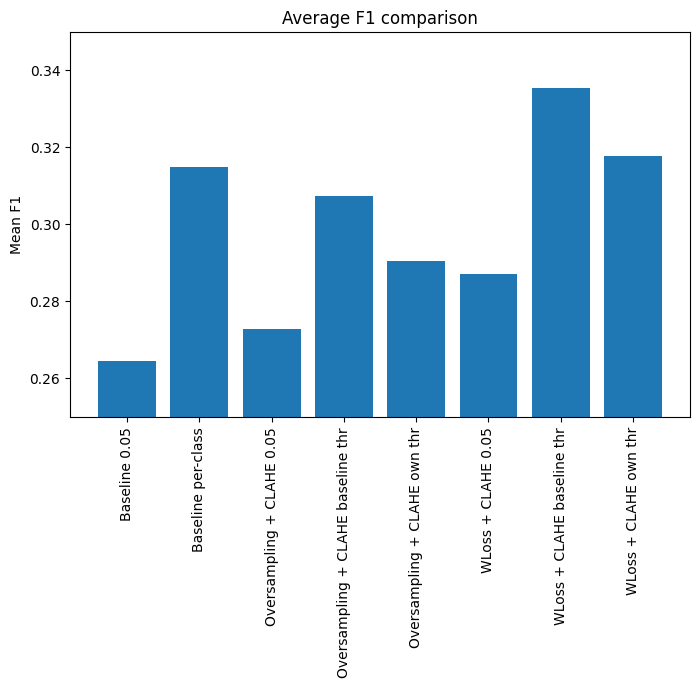

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["Model"], summary_df["F1"])
plt.ylabel("Mean F1")
plt.title("Average F1 comparison")
plt.xticks(rotation=90)
plt.ylim(0.25, 0.35)
plt.show()

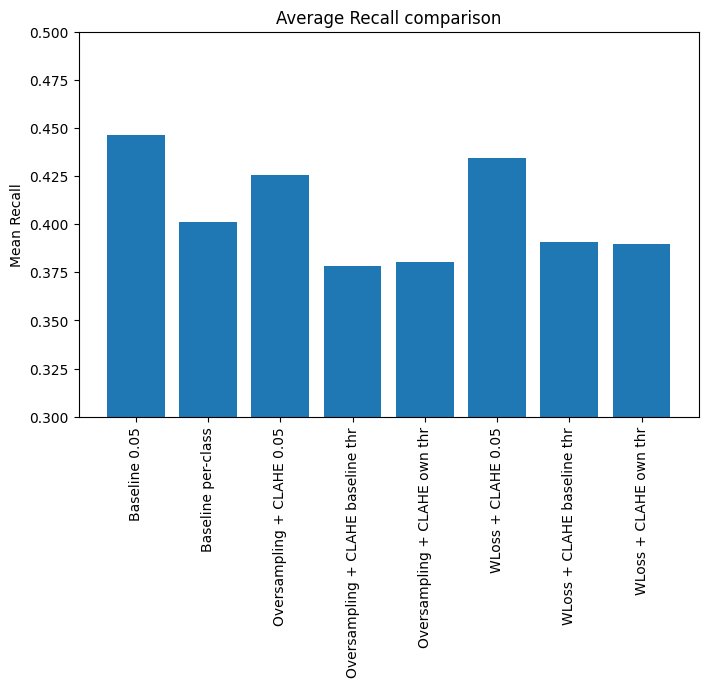

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["Model"], summary_df["Recall"])
plt.ylabel("Mean Recall")
plt.title("Average Recall comparison")
plt.xticks(rotation=90)
plt.ylim(0.3, 0.5)
plt.show()

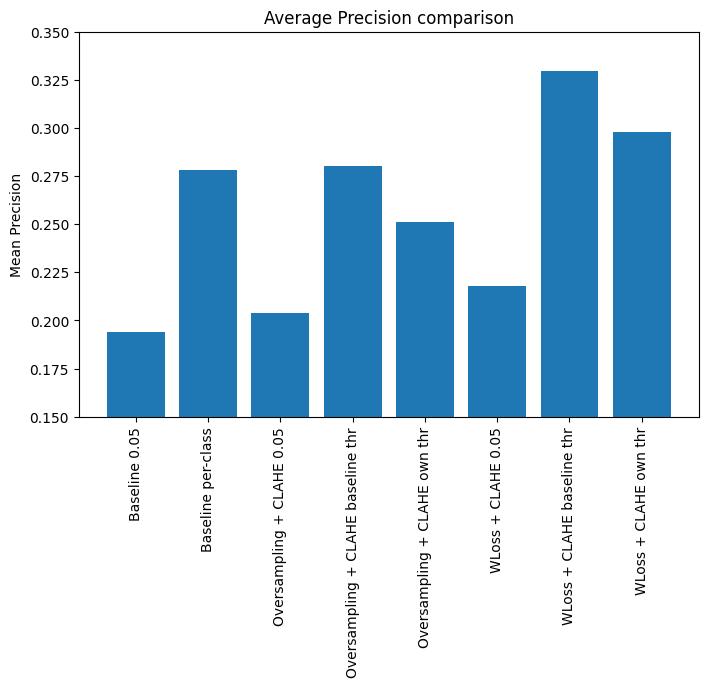

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["Model"], summary_df["Precision"])
plt.ylabel("Mean Precision")
plt.title("Average Precision comparison")
plt.xticks(rotation=90)
plt.ylim(0.15, 0.35)
plt.show()

Использование разных порогов значительно улучшило `precision` и итоговый `F1-score` по сравнению с единым порогом 0.05. Лучший результат показала модель с `Weighted Loss + CLAHE` и бейзлайновыми порогами. `Oversampling` дал менее стабильный эффект и в ряде случаев ухудшал качество из-за роста количества FP. В целом `Weighted Los`s оказался более эффективным способом борьбы с дисбалансом классов. При этом модели с единым порогом показывали более высокий `recall`, но существенно уступали по `precision`.

#### В разрезе частоты классов

In [ ]:
RARE_CLASSES = [1, 2, 4, 12]
MEDIUM_CLASSES = [5, 6, 7, 9, 10]
FREQUENT_CLASSES = [0, 3, 8, 11, 13]

GROUPS = {
    "Rare": RARE_CLASSES,
    "Medium": MEDIUM_CLASSES,
    "Frequent": FREQUENT_CLASSES,
}

In [ ]:
rows = []

models = {
    "Baseline 0.05": baseline_df,
    "Baseline per-class": baseline_thr_df,
    "Oversampling + CLAHE 0.05": oversampling_clahe_one_thr_df,
    "Oversampling + CLAHE baseline thr": oversampling_clahe_baseline_thr_df,
    "Oversampling + CLAHE own thr": oversampling_clahe_own_thr_df,
    "WLoss + CLAHE 0.05": wloss_clahe_one_thr_df,
    "WLoss + CLAHE baseline thr": wloss_clahe_baseline_thr_df,
    "WLoss + CLAHE own thr": wloss_clahe_own_thr_df,
}

for group_name, class_ids in GROUPS.items():
    for model_name, df in models.items():
        value = df[df["class_id"].isin(class_ids)]["F1"].mean()

        rows.append({
            "Group": group_name,
            "Model": model_name,
            "F1": value,
        })

f1_groups_df = pd.DataFrame(rows)
f1_groups_df

,Group,Model,F1
0,Rare,Baseline 0.05,0.099125
1,Rare,Baseline per-class,0.120400
2,Rare,Oversampling + CLAHE 0.05,0.124050
3,Rare,Oversampling + CLAHE baseline thr,0.116500
4,Rare,Oversampling + CLAHE own thr,0.095575
5,Rare,WLoss + CLAHE 0.05,0.149125
6,Rare,WLoss + CLAHE baseline thr,0.170225
7,Rare,WLoss + CLAHE own thr,0.134450
8,Medium,Baseline 0.05,0.227980
9,Medium,Baseline per-class,0.276640


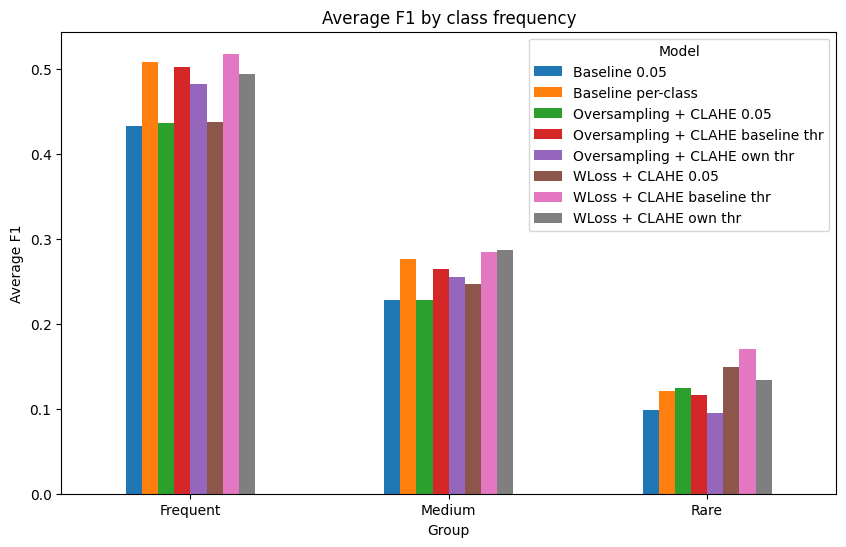

In [ ]:
pivot_f1 = f1_groups_df.pivot(
    index="Group",
    columns="Model",
    values="F1"
)

pivot_f1.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Average F1")
plt.title("Average F1 by class frequency")
plt.xticks(rotation=0)
plt.show()

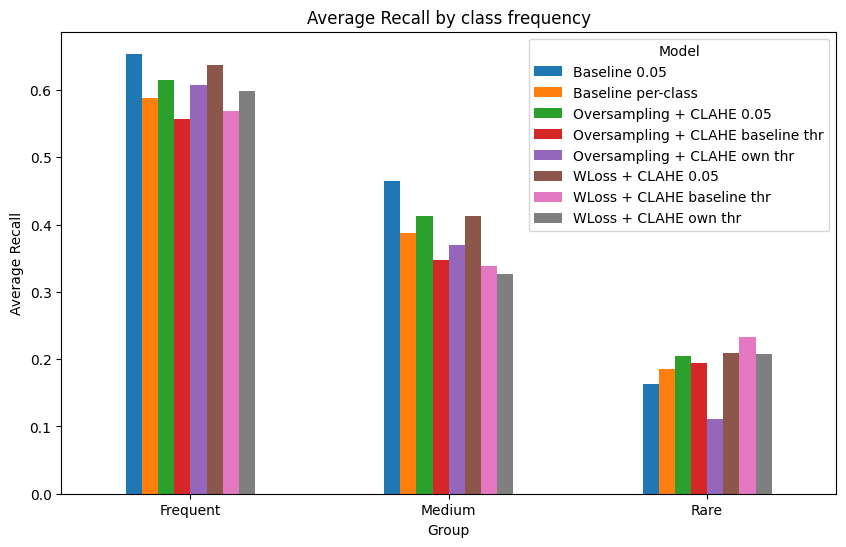

In [ ]:
rows = []
for group_name, class_ids in GROUPS.items():
    for model_name, df in models.items():
        value = df[df["class_id"].isin(class_ids)]["Recall"].mean()

        rows.append({
            "Group": group_name,
            "Model": model_name,
            "Recall": value,
        })

recall_groups_df = pd.DataFrame(rows)
recall_groups_df

pivot_recall = recall_groups_df.pivot(
    index="Group",
    columns="Model",
    values="Recall"
)

pivot_recall.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Average Recall")
plt.title("Average Recall by class frequency")
plt.xticks(rotation=0)
plt.show()

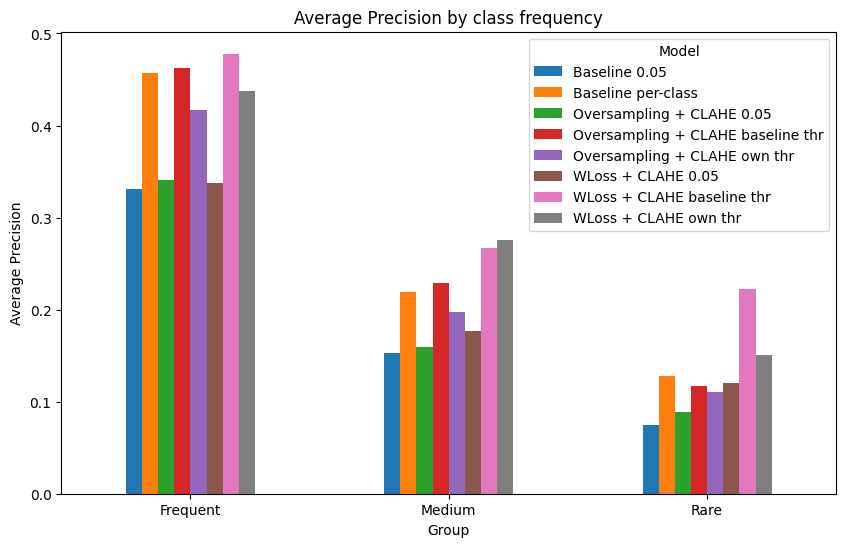

In [ ]:
rows = []
for group_name, class_ids in GROUPS.items():
    for model_name, df in models.items():
        value = df[df["class_id"].isin(class_ids)]["Precision"].mean()

        rows.append({
            "Group": group_name,
            "Model": model_name,
            "Precision": value,
        })

precision_groups_df = pd.DataFrame(rows)
precision_groups_df

pivot_precision = precision_groups_df.pivot(
    index="Group",
    columns="Model",
    values="Precision"
)

pivot_precision.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Average Precision")
plt.title("Average Precision by class frequency")
plt.xticks(rotation=0)
plt.show()

Все модели значительно лучше работают с более частыми классами. Применение `oversampling` и `weighted loss` не помогло повысить метрики хотя бы до уровня средних по частоте классов.

Использование разных порогов стабильно улучшало `precision` и `F1-score` для всех групп классов. Наилучшие результаты для частым и средним классам показала модель `Weighted Loss + CLAHE baseline thr`. Для редких классов `weighted loss` также оказался наиболее эффективным методом и дал лучший средний `F1-score` среди всех рассмотренных конфигураций.

`Oversampling` улучшал `recall` редких классов, однако часто сопровождался ростом `FP` и снижением `precision`, из-за чего итоговый `F1-score` увеличивался незначительно.

#### В разрезе классов

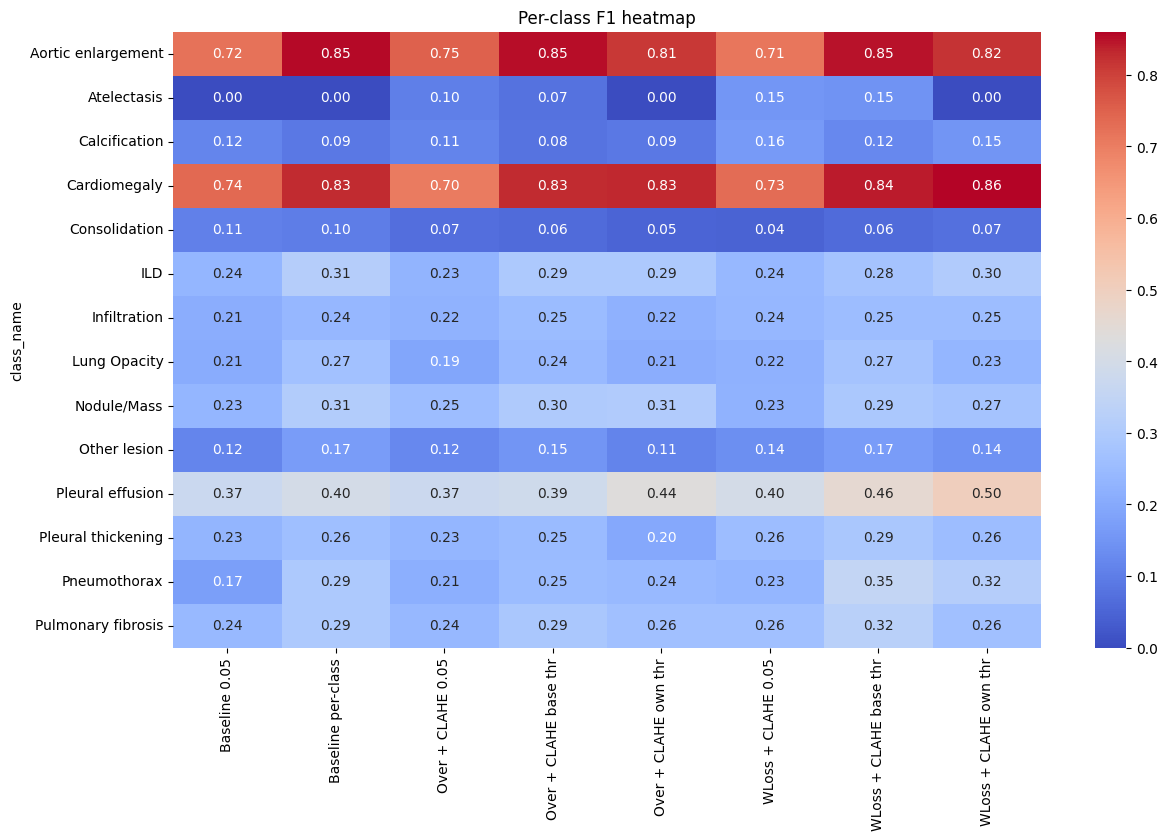

In [ ]:
heatmap_f1 = pd.DataFrame({
    "Baseline 0.05": baseline_df.set_index("class_name")["F1"],
    "Baseline per-class": baseline_thr_df.set_index("class_name")["F1"],
    "Over + CLAHE 0.05": oversampling_clahe_one_thr_df.set_index("class_name")["F1"],
    "Over + CLAHE base thr": oversampling_clahe_baseline_thr_df.set_index("class_name")["F1"],
    "Over + CLAHE own thr": oversampling_clahe_own_thr_df.set_index("class_name")["F1"],
    "WLoss + CLAHE 0.05": wloss_clahe_one_thr_df.set_index("class_name")["F1"],
    "WLoss + CLAHE base thr": wloss_clahe_baseline_thr_df.set_index("class_name")["F1"],
    "WLoss + CLAHE own thr": wloss_clahe_own_thr_df.set_index("class_name")["F1"],
})

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_f1,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Per-class F1 heatmap")
plt.show()

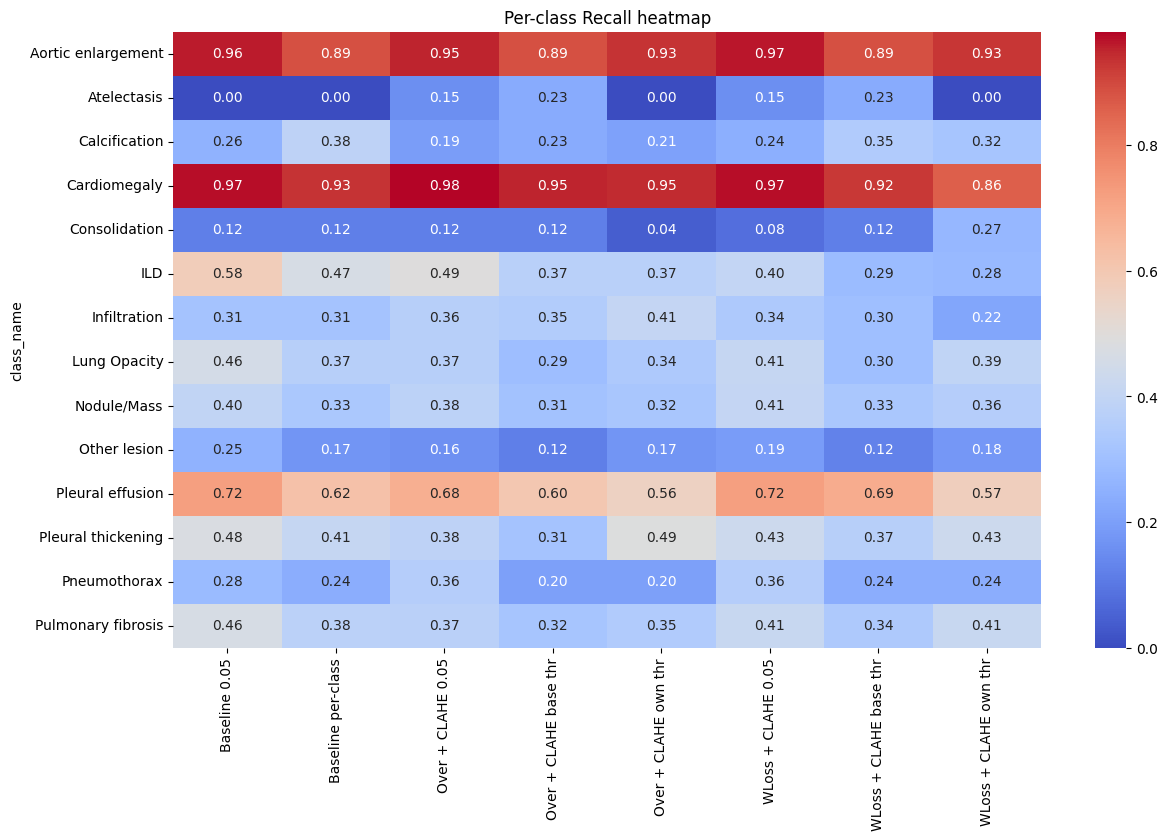

In [ ]:
heatmap_recall = pd.DataFrame({
    "Baseline 0.05": baseline_df.set_index("class_name")["Recall"],
    "Baseline per-class": baseline_thr_df.set_index("class_name")["Recall"],
    "Over + CLAHE 0.05": oversampling_clahe_one_thr_df.set_index("class_name")["Recall"],
    "Over + CLAHE base thr": oversampling_clahe_baseline_thr_df.set_index("class_name")["Recall"],
    "Over + CLAHE own thr": oversampling_clahe_own_thr_df.set_index("class_name")["Recall"],
    "WLoss + CLAHE 0.05": wloss_clahe_one_thr_df.set_index("class_name")["Recall"],
    "WLoss + CLAHE base thr": wloss_clahe_baseline_thr_df.set_index("class_name")["Recall"],
    "WLoss + CLAHE own thr": wloss_clahe_own_thr_df.set_index("class_name")["Recall"],
})

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_recall,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Per-class Recall heatmap")
plt.show()

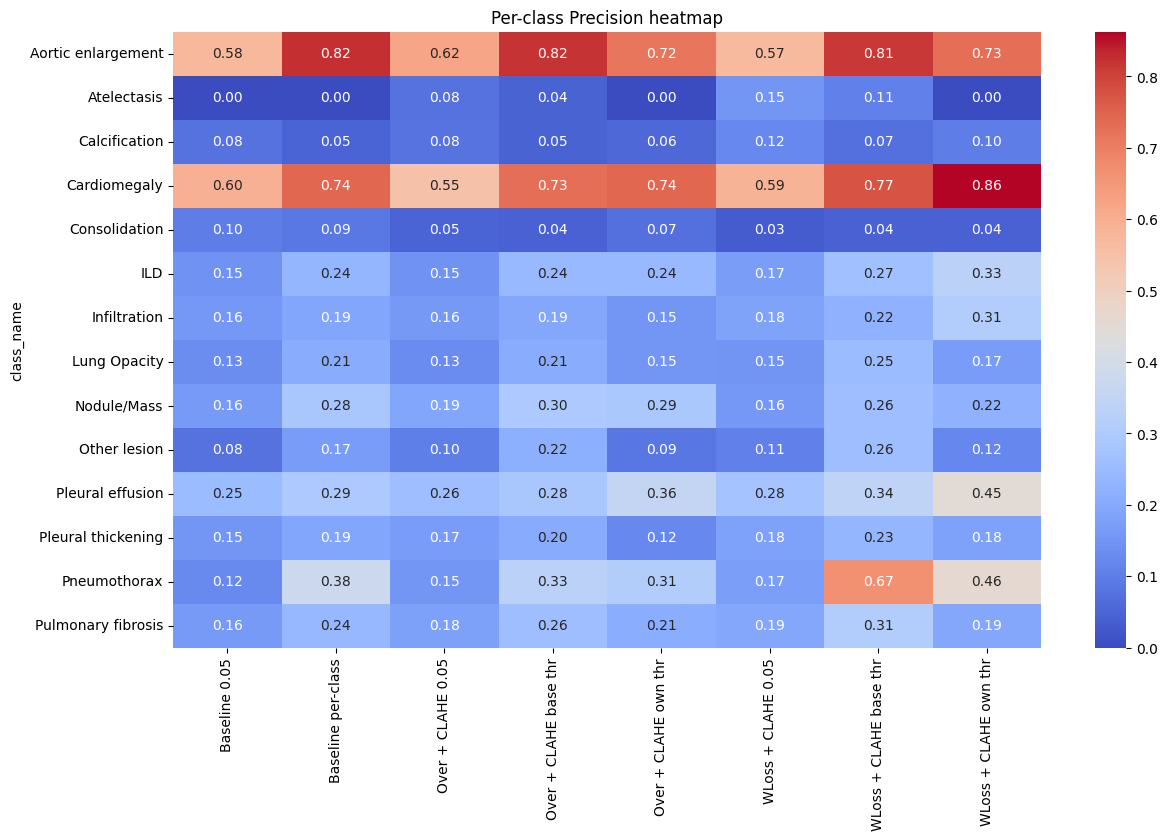

In [ ]:
heatmap_precision = pd.DataFrame({
    "Baseline 0.05": baseline_df.set_index("class_name")["Precision"],
    "Baseline per-class": baseline_thr_df.set_index("class_name")["Precision"],
    "Over + CLAHE 0.05": oversampling_clahe_one_thr_df.set_index("class_name")["Precision"],
    "Over + CLAHE base thr": oversampling_clahe_baseline_thr_df.set_index("class_name")["Precision"],
    "Over + CLAHE own thr": oversampling_clahe_own_thr_df.set_index("class_name")["Precision"],
    "WLoss + CLAHE 0.05": wloss_clahe_one_thr_df.set_index("class_name")["Precision"],
    "WLoss + CLAHE base thr": wloss_clahe_baseline_thr_df.set_index("class_name")["Precision"],
    "WLoss + CLAHE own thr": wloss_clahe_own_thr_df.set_index("class_name")["Precision"],
})

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_precision,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Per-class Precision heatmap")
plt.show()

Heatmap показывает, что качество модели сильно зависит от класса патологии. Наилучшие результаты во всех конфигурациях достигаются для `Aortic enlargement` и `Cardiomegaly`. Для редких и сложных классов, таких как `Atelectasis`, `Consolidation` и `Calcification`, качество остается низким независимо от используемого метода.

Использование разных порогов почти во всех случаях повышало `precision` и итоговый `F1-score` по сравнению с единым порогом 0.05. Наиболее стабильные результаты показала модель `Weighted Loss + CLAHE baseline thr`, особенно для средних и частых классов.

`Oversampling` чаще увеличивал `recall`, однако одновременно повышал количество `FP`, из-за чего `precision` и итоговый `F1-score` улучшались не всегда. `Weighted Loss` оказался более устойчивым подходом для работы с дисбалансом классов.

### Анализ False Positives и False Negatives

In [ ]:
BEST_IMG_DIR = ROOT / "images/test"
BEST_GT_DIR = ROOT / "labels/test"

BEST_PRED_DIR = PRED_ROOT / "test_preds_clahe_wloss_baseline_threshold" / "labels"

fp_df, fn_df = collect_fp_fn_errors(
    img_dir=BEST_IMG_DIR,
    gt_dir=BEST_GT_DIR,
    pred_dir=BEST_PRED_DIR,
    class_names=CLASS_NAMES,
    iou_thr=0.5
)

fp_df.head(100)

,image_id,image_path,class_id,class_name,conf,box
0,98f00bae3d65ebcebd046c12e5b27f7c,/home/katyukh/projects/VinBigData/yolo_data/im...,12,Pneumothorax,0.829213,"[53.756047499999994, 165.412352, 364.8568605, ..."
1,13776ecb39222a7aaace2d9721abebbe,/home/katyukh/projects/VinBigData/yolo_data/im...,10,Pleural effusion,0.804460,"[162.50368, 170.68471, 495.750144, 763.965538]"
2,5b295b1def2ae7beedc752eb0fd668aa,/home/katyukh/projects/VinBigData/yolo_data/im...,7,Lung Opacity,0.799457,"[161.92161499999997, 216.04710399999996, 416.9..."
3,d99f39f7af1ef7616ccf4be531a2fec7,/home/katyukh/projects/VinBigData/yolo_data/im...,3,Cardiomegaly,0.794189,"[373.12455600000004, 517.035008, 812.876796, 7..."
4,ce4e8ead795a19444e7b9dc1c27cfb66,/home/katyukh/projects/VinBigData/yolo_data/im...,0,Aortic enlargement,0.789185,"[459.1633584999999, 224.590848, 579.5313755, 3..."
...,...,...,...,...,...,...
95,1f68a73472d32146d1cbe3bcd9355337,/home/katyukh/projects/VinBigData/yolo_data/im...,0,Aortic enlargement,0.617207,"[529.695474, 252.54656, 648.836118, 392.41984]"
96,529de882ae3a391433f264483777a0b8,/home/katyukh/projects/VinBigData/yolo_data/im...,0,Aortic enlargement,0.616977,"[389.4373665, 348.337408, 476.2276155, 449.143..."
97,ee915f3c066c9435c5403584e000777f,/home/katyukh/projects/VinBigData/yolo_data/im...,3,Cardiomegaly,0.616783,"[302.309028, 573.5418880000001, 699.244308, 74..."
98,0211f9fe31142ba1e25fb6a2ea3fea38,/home/katyukh/projects/VinBigData/yolo_data/im...,0,Aortic enlargement,0.616142,"[412.47583649999996, 237.9496448, 502.1489655,..."


In [ ]:
ERROR_ROOT = PROJECT_ROOT / "error_analysis"
ERROR_ROOT.mkdir(parents=True, exist_ok=True)

fp_df.head(100).to_csv(ERROR_ROOT / "top_100_false_positives.csv", index=False)
fn_df.head(100).to_csv(ERROR_ROOT / "top_100_false_negatives.csv", index=False)

In [ ]:
FP_IMG_DIR = ERROR_ROOT / "false_positives"
FN_IMG_DIR = ERROR_ROOT / "false_negatives"

FP_IMG_DIR.mkdir(parents=True, exist_ok=True)
FN_IMG_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
save_fp_images(fp_df, FP_IMG_DIR, top_n=100)
save_fn_images(fn_df, FN_IMG_DIR, top_n=100)

print("Saved FP images:", len(list(FP_IMG_DIR.glob("*.png"))))
print("Saved FN images:", len(list(FN_IMG_DIR.glob("*.png"))))

Saved FP images: 100
Saved FN images: 100


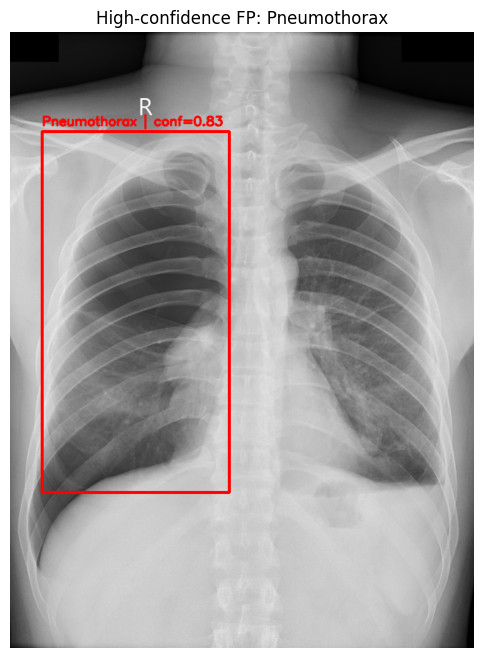

In [ ]:
top_fp = (
    fp_df
    .sort_values("conf", ascending=False)
    .iloc[0]
)

show_error(
    top_fp,
    title=f'High-confidence FP: {top_fp["class_name"]}',
    color=(255, 0, 0)
)

Модель уверенно предсказала Pneumothorax в большой области правого легкого, хотя легкое нормального размера.

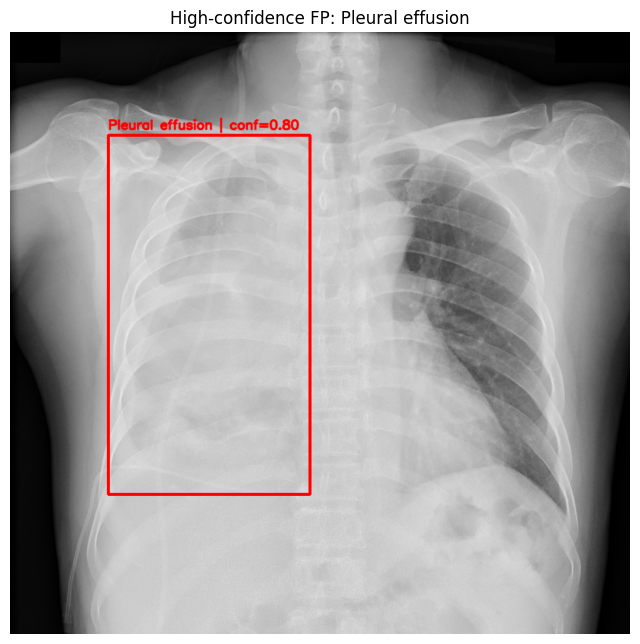

In [ ]:
top_fp2 = (
    fp_df
    .sort_values("conf", ascending=False)
    .iloc[1]
)

show_error(
    top_fp2,
    title=f'High-confidence FP: {top_fp2["class_name"]}',
    color=(255, 0, 0)
)

Модель выделила крупную область затемнения как Pleural effusion.

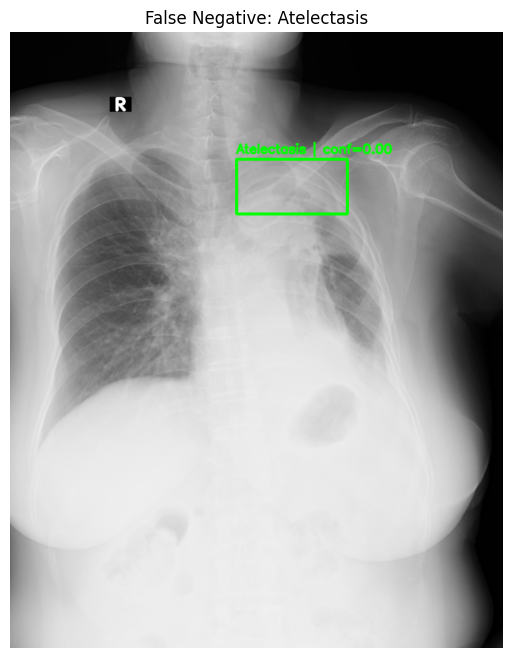

In [ ]:
fn_atelectasis = (
    fn_df[fn_df["class_name"] == "Atelectasis"]
    .iloc[0]
)

show_error(
    fn_atelectasis,
    title="False Negative: Atelectasis",
    color=(0, 255, 0)
)

Модель не обнаружила Atelectasis. Вероятная причина - малое количество примеров данного класса. Также, Atelectasis это глобальный паттерн (уменьшение легкого/спадение легочной ткани), и модель детекции может его плохо улавливать.

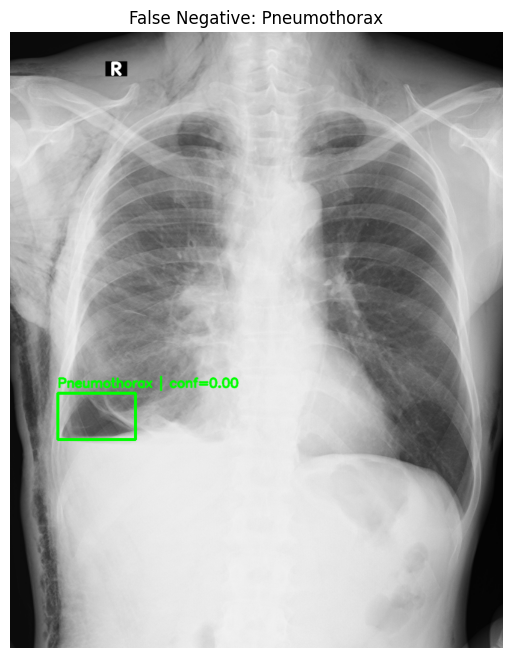

In [ ]:
fn_pneumo = (
    fn_df[fn_df["class_name"] == "Pneumothorax"]
    .iloc[0]
)

show_error(
    fn_pneumo,
    title="False Negative: Pneumothorax",
    color=(0, 255, 0)
)

Небольшая область Pneumothorax не была обнаружена моделью. Здесь такая же специфика как с Atelectasis.

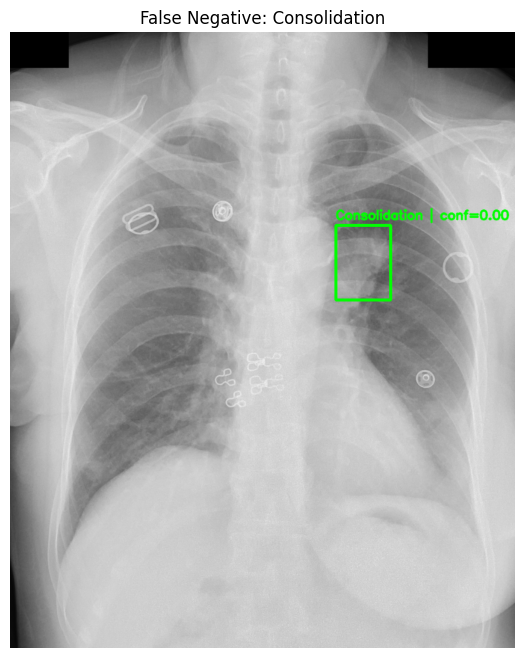

In [ ]:
fn_cons = (
    fn_df[fn_df["class_name"] == "Consolidation"]
    .iloc[0]
)

show_error(
    fn_cons,
    title="False Negative: Consolidation",
    color=(0, 255, 0)
)

Модель пропустила локальную область Consolidation с нечеткими границами

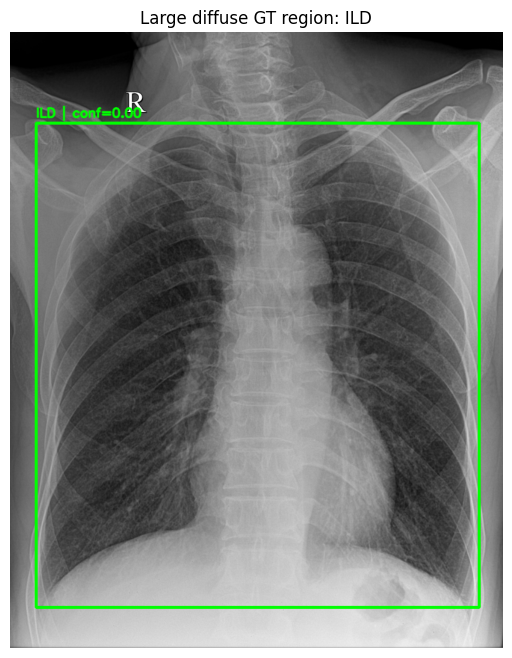

In [ ]:
fn_df["area"] = fn_df["box"].apply(
    lambda b: (b[2] - b[0]) * (b[3] - b[1])
)

large_case = (
    fn_df
    .sort_values("area", ascending=False)
    .iloc[0]
)

show_error(
    large_case,
    title=f'Large diffuse GT region: {large_case["class_name"]}',
    color=(0, 255, 0)
)

Для ILD бокс занимает почти весь снимок, что затрудняет точную локализацию. Подобные диффузные патологии хуже подходят для детекции и могут требовать сегментационных моделей.

`FP` часто возникали на больших контрастных областях лeгких или рядом с реальными патологиями, что может указывать на то, что модель обнаруживала аномальную область, но ошибалась в определении класса патологии.

`FN` особенно часто встречались для редких и небольших локальных патологий, таких как `Atelectasis` и `Pneumothorax`. Во многих случаях эти области были визуально слабо выражены или занимали небольшую часть изображения, из-за чего модель их пропускала.

Также было замечено, что диффузные патологии, например `ILD`, могут занимать практически все пространство и иметь размытые границы. Такие случаи плохо подходят детекции, поскольку точная локализация объекта становится затруднительной.

## 5. Общий вывод

В работе была исследована **задача детекции патологий грудной клетки** на датасете `VinBigData Chest X-ray Abnormalities Detection` с использованием `YOLO11`. Основной проблемой датасета оказался сильный **дисбаланс классов**: некоторые патологии содержали менее 50 объектов в train set, тогда как частые классы имели более 1500–2000 объектов.

Базовая модель YOLO11 показала хорошее качество для частых патологий, таких как `Aortic enlargement` и `Cardiomegaly`, однако практически не детектировала редкие классы. Особенно проблемными оказались `Atelectasis`, `Consolidation` и `Pneumothorax`.

**Для борьбы с дисбалансом были исследованы несколько подходов:**

- per-class threshold tuning,
- oversampling редких классов,
- CLAHE preprocessing,
- weighted loss.

`Подбор отдельных порогов` для каждого класса **дал наиболее стабильное улучшение качества**. Такой подход значительно повысил `precision` и общий `F1-score` по сравнению с единым порогом 0.05.

`Oversampling` редких классов вместе с `CLAHE` позволил модели начать детектировать `Atelectasis`, однако не дал устойчивого роста общего качества. Поскольку `oversampling` выполнялся на уровне изображений, вместе с редкими патологиями также дублировались частые классы, присутствующие на тех же снимках. Это **не позволило исправить дисбаланс**, но увеличло число примеров редких классов.

**Наиболее успешным методом оказался** `Weighted Loss + CLAHE` в сочетании с бейзлайновыми порогами. Этот вариант показал лучший средний `F1-score` и улучшил качество для ряда редких патологий, включая `Atelectasis`, `Pneumothorax` и `Calcification`, при сохранении высокого качества на частых классах.

Также, **часть патологий плохо подходит для детекции** с bbox-разметкой. Например, `Atelectasis` часто проявляется как изменение объема легочной ткани, а не как локальный объект с четкими границами. Это делает задачу разметки и обучения детектора существенно сложнее и может ограничивать итоговое качество модели.

**Лучший итоговый результат показал вариант Weighted Loss + CLAHE с бейзлайновыми порогами. Этот подход обеспечил наиболее сбалансированное качество между частыми и редкими патологиями.**